# Bitcoin Demand Dynamics

### Where the bids come from, what they paid, and how much of it we can see

Bitcoin's supply is fixed, scheduled and public. Demand is none of those things — and it is not one thing either.

The chain records coins moving, but it does not record a buyer, a seller or the price they agreed on. Some demand appears on-chain, some appears in fund disclosures and company filings, and some appears only in the market price. What we can measure is not demand itself, but the evidence it leaves behind.

Coins are acquired by miners, by people holding their own keys, through exchange-traded funds, by company treasuries and by governments. Those groups have almost nothing in common. They acquire coins in different ways, leave different kinds of evidence behind, and sit at very different distances from what the ledger can see.

This notebook takes them one at a time and asks the same three questions of each:

**How do they acquire coins?** Miners commit hardware and electricity to earn newly issued subsidy coins and transaction fees. Everyone else acquires coins that already exist, receives them through another process, or buys shares in a wrapper that holds them.

**What evidence is there that they did?** Block rewards and difficulty are written into the protocol. Mining power expense has to be estimated. A fund publishes daily. A company files periodically. A government often publishes nothing.

**What can we say about what they paid?** Sometimes there is a direct record. More often there is a proxy: estimated mining power expense, the price when a UTXO last moved, or a reference reconstructed from fund flows. Those measures answer different questions, so the notebook keeps them separate rather than calling all of them cost basis.

| Section | Who or what we can see | How we see it | What it can tell us |
|---|---|---|---|
| 1 | Miners | Protocol data, fleet efficiency and power-price scenarios | New issuance, fees and security expenditure |
| 2 | On-chain participation | Funded addresses, realized price and owner estimates | How the ownership proxies grow — and where they stop tracking |
| 3 | US spot ETF trusts | Published holdings and daily net flows | A documented stock and flow for one channel of demand |
| 4 | Companies and governments | Filed, announced and estimated positions | Who holds selected reserves and how those coins were acquired |
| 5 | The market price | Models built on user counts, and on time | What the history looks like under different assumptions |

Where the data allows it, each section asks two more questions: **how large is this channel relative to new issuance, and is its latest observable flow positive or negative?** A holding is not a flow, a transfer is not always a purchase, and a fitted line is not a forecast — but each can still tell us something when it is read for what it is.

The order runs from the evidence the protocol records most clearly to the evidence that has to be assembled from filings, estimates and market history. By the end, the list of identifiable buyers has run out. That is the point: bitcoin demand is real, but much of it can only be seen indirectly.

---

*Data: BRK on-chain metrics and Coin Metrics Labs mining efficiency from the [Bitcoin Report Library](https://github.com/SecretSatoshis/Bitcoin-Report-Library), the Secret Satoshis ETF dataset, CoinGecko public treasuries, Secret Satoshis government classifications, Crypto.com owner estimates, and World Bank / Our World in Data technology adoption. See [Data sources and terms](#Data-sources-and-terms) at the end.*

## Setup

The notebook loads the repository's supply and demand release from `data/research/`, built from the Bitcoin Report Library and already checked for missing dates, totals that add up and the expected gaps in coverage; the checks below confirm every file matches the release manifest. Company and government treasuries are read from CoinGecko when the notebook runs and are not stored in the repository.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/bitcoin_investment_strategy").is_dir()), None)
if ROOT is None:
    raise ValueError("Run this notebook from the repository or its notebooks directory")
DATA = ROOT / "data/research"
DATA_MANIFEST_PATH = DATA / "manifests/data_manifest.json"
import sys
sys.path.insert(0, str(ROOT / "src"))
from bitcoin_investment_strategy.research.analysis import (
    apply_research_theme, BLUE, RED, GREEN, GREY, ORANGE, PRIMARY,
    covered_periods, forward_change, compact, hashes, log_axis, thousands, usd,
    period_centers, price_axis, finish, halving_dates, BRK, COIN_METRICS, WORLD_BANK, OWID,
    CRYPTO_COM, CLASSIFICATION, COINGECKO, ETF_DATASET,
)
from bitcoin_investment_strategy.io import verify_artifacts
from bitcoin_investment_strategy.savings import prepare_prices

# The Secret Satoshis dark chart theme and brand palette, shared with the supply notebook.
apply_research_theme()


# ------------------------------------------------------- chart helpers
# Shared helpers (compact, hashes, usd, log_axis, period_centers, price_axis, finish) live in
# bitcoin_investment_strategy.research.analysis so both notebooks format charts the same way.
def complete_periods(idx, code, first=None, last=None):
    """True where a resampled period is fully covered by the data.

    A half-finished month set beside complete ones is an artifact of the
    calendar rather than anything about bitcoin, so those bars are drawn apart.
    """
    first = FIRST_DAY if first is None else first
    last = LAST_DAY if last is None else last
    return covered_periods(idx, code, first, last)


print("Ready.")

Ready.


## The data we pull

The inputs answer different questions, and each one can be pushed only so far.

| Group | Series | The question it answers |
|---|---|---|
| **Protocol and market** | `price`, `supply`, daily subsidy, daily fees | Price history, coins outstanding, new issuance, and fees paid to miners |
| **Mining** | `hash_rate`, `difficulty`, `cm_efficiency_j_gh` | How much work is being done, how it adjusts, and how much power it takes |
| **Participation proxies** | funded-address thresholds, realized price | What the ledger holds and when it last moved — not who owns it or what they paid |
| **Adoption estimates** | Crypto.com market sizing, internet adoption | Roughly how many people, next to a technology somebody measured all the way through |
| **Reported holdings** | ETF, company, and government tables | Dated positions, and daily coins in and out of the ETF trusts |

The first three are daily series. The last two are not series at all — they are snapshots and annual estimates, and that difference is what the next section is about.

In [2]:
manifest = json.loads(DATA_MANIFEST_PATH.read_text())
INPUT_FILES = {
    "daily": DATA / "bitcoin_daily.csv",
    "owners": DATA / "bitcoin_owner_estimates.csv",
    "adoption": DATA / "technology_adoption_annual.csv",
    "etf_daily": DATA / "etf_daily.csv",
    "etf_totals": DATA / "etf_totals_daily.csv",
    "etf_quarterly": DATA / "etf_quarterly.csv",
}
verify_artifacts(manifest, ROOT, INPUT_FILES.values())

daily = pd.read_csv(INPUT_FILES["daily"], parse_dates=["date"]).set_index("date")
owners = pd.read_csv(INPUT_FILES["owners"])
adoption = pd.read_csv(INPUT_FILES["adoption"])
# CoinGecko's treasury snapshots, read live (or from a local copy under a day old).
from bitcoin_investment_strategy.research.treasuries import load_treasuries
companies, governments = load_treasuries()

print(f"release         {manifest['release_id']}")
print(f"daily series    {daily.index.min().date()} to {daily.index.max().date()}  "
      f"({len(daily):,} rows x {daily.shape[1]} columns)")
print(f"owner estimates {len(owners)} annual from Crypto.com, {owners.year.min()}-{owners.year.max()}")
print(f"companies       {companies['btc'].notna().sum()} CoinGecko positions")
print(f"governments     {len(governments)} CoinGecko positions")

efficiency_source = manifest["sources"]["coinmetrics_efficiency"]
print(f"Mining efficiency observed through {efficiency_source['observation_end']}; carried {efficiency_source['carried_days']} days (maximum 365).")

print("Data cutoff:", manifest["core_data_end"])
for source_name in ["companies", "governments"]:
    frame = companies if source_name == "companies" else governments
    print(f"{source_name} snapshot dates: {frame.as_of.min()} to {frame.as_of.max()}")

from bitcoin_investment_strategy.research.analysis import release_age_note, snapshot_date_note
for note in (release_age_note(manifest["core_data_end"]),
             snapshot_date_note(companies["as_of"], manifest["core_data_end"], "company"),
             snapshot_date_note(governments["as_of"], manifest["core_data_end"], "government")):
    if note:
        print(note)


release         2026-10-01-aa04e5d9d0ff
daily series    2010-01-01 to 2026-10-01  (6,118 rows x 51 columns)
owner estimates 6 annual from Crypto.com, 2020-2025
companies       180 CoinGecko positions
governments     13 CoinGecko positions
Mining efficiency observed through 2026-08-31; carried 31 days (maximum 365).
Data cutoff: 2026-10-01
companies snapshot dates: 2026-10-02 to 2026-10-02
governments snapshot dates: 2026-10-02 to 2026-10-02
NOTE: 180 company snapshot(s) are dated after the 2026-10-01 data cutoff (latest 2026-10-02); they are compared with cutoff-day supply.
NOTE: 13 government snapshot(s) are dated after the 2026-10-01 data cutoff (latest 2026-10-02); they are compared with cutoff-day supply.


### What counts as evidence

The ledger records what happened to coins: which outputs exist, what the block reward was, how hard the work was, and when. It does not record who owns anything, who sold to whom, what dollars changed hands, or why. Anything about buyers has to come from outside the chain — and coming from outside means it does not inherit the chain's certainty just because it is about bitcoin.

So every number here sits in one of four tiers, and the tier decides how hard it can be leaned on. A number can be calculated exactly from an input that was only a guess; clean arithmetic does not clean up the input.

| Tier | What it is | What it supports |
|---|---|---|
| **From the protocol** | Difficulty, subsidy, fees, supply, funded addresses | Anyone can recompute it and get the same answer |
| **Disclosed by someone** | ETF trust balances, dated company filings | What that entity reported, on that date |
| **Estimated** | Owner market sizing, inferred government holdings, fleet efficiency | Rough size and direction, only as good as the method behind it |
| **Fitted** | The n² rule, the power-law time fit | A description of history under stated assumptions — not a cause, not a forecast |

Two quirks in the daily series need handling first, and both are the same kind of trap: a number that looks usable and is not.

**The price series begins in August 2010.** Coins changed hands before that, privately and in small quoted amounts, but not in this dataset. So `price` and `market_cap_usd` stay empty beforehand rather than being filled with zeros, which would quietly drag down every average that touched them.

In [3]:
def validate(df):
    """Report where the record and its prices begin.

    The release checks already guarantee a complete, gap-free calendar to the cutoff and
    carry mining efficiency forward, so nothing here needs repairing.
    """
    print(f"  record begins {df.index[0].date()}, {(df.index[0] - pd.Timestamp('2009-01-03')).days} days "
          "after the genesis block")
    first_price = prepare_prices(df["price"]).index[0]
    print(f"  BRK price coverage begins {first_price.date()} — "
          f"{int((df.index < first_price).sum())} earlier rows are unpriced")
    return df, first_price


print("Validating:")
daily, FIRST_PRICE = validate(daily)
# Daily flows are differences from the day before, so a period counts as complete only
# from the first day that has one.
FIRST_DAY = daily["subsidy_daily"].first_valid_index()
LAST_DAY = daily.index.max()

priced = daily.loc[FIRST_PRICE:]          # everything that needs a price
print(f"\nfull record   {daily.index.min().date()} to {LAST_DAY.date()}  ({len(daily):,} days)")
print(f"priced record {FIRST_PRICE.date()} to {LAST_DAY.date()}  ({len(priced):,} days)")

Validating:
  record begins 2010-01-01, 363 days after the genesis block
  BRK price coverage begins 2010-08-16 — 227 earlier rows are unpriced

full record   2010-01-01 to 2026-10-01  (6,118 days)
priced record 2010-08-16 to 2026-10-01  (5,891 days)


---

# 1. Mining: security expenditure and new issuance

Bitcoin is created by miners.

A miner gathers up transactions and searches for a block hash below a target. Whoever finds one first receives newly issued coins plus the fees attached to the transactions they included. Only the new coins expand supply; the fees come out of existing holders' balances.

This is a purchase, but it is not an auction. The protocol is not selling to the highest bidder — every miner is running the same lottery, and spending more buys more tickets rather than a claim on the next block. Miners pay for power, hardware, staff, financing and premises long before they find out whether any of it earned them a coin.

What that gives us is a buyer whose costs can be estimated from the outside. What it costs us is precision: hashrate is inferred rather than metered, fleet efficiency is modeled, and the electricity price is a scenario. The subsidy schedule and the fees actually paid are much firmer ground.

The panels separate coins outstanding, monthly issuance, and fees paid to miners.

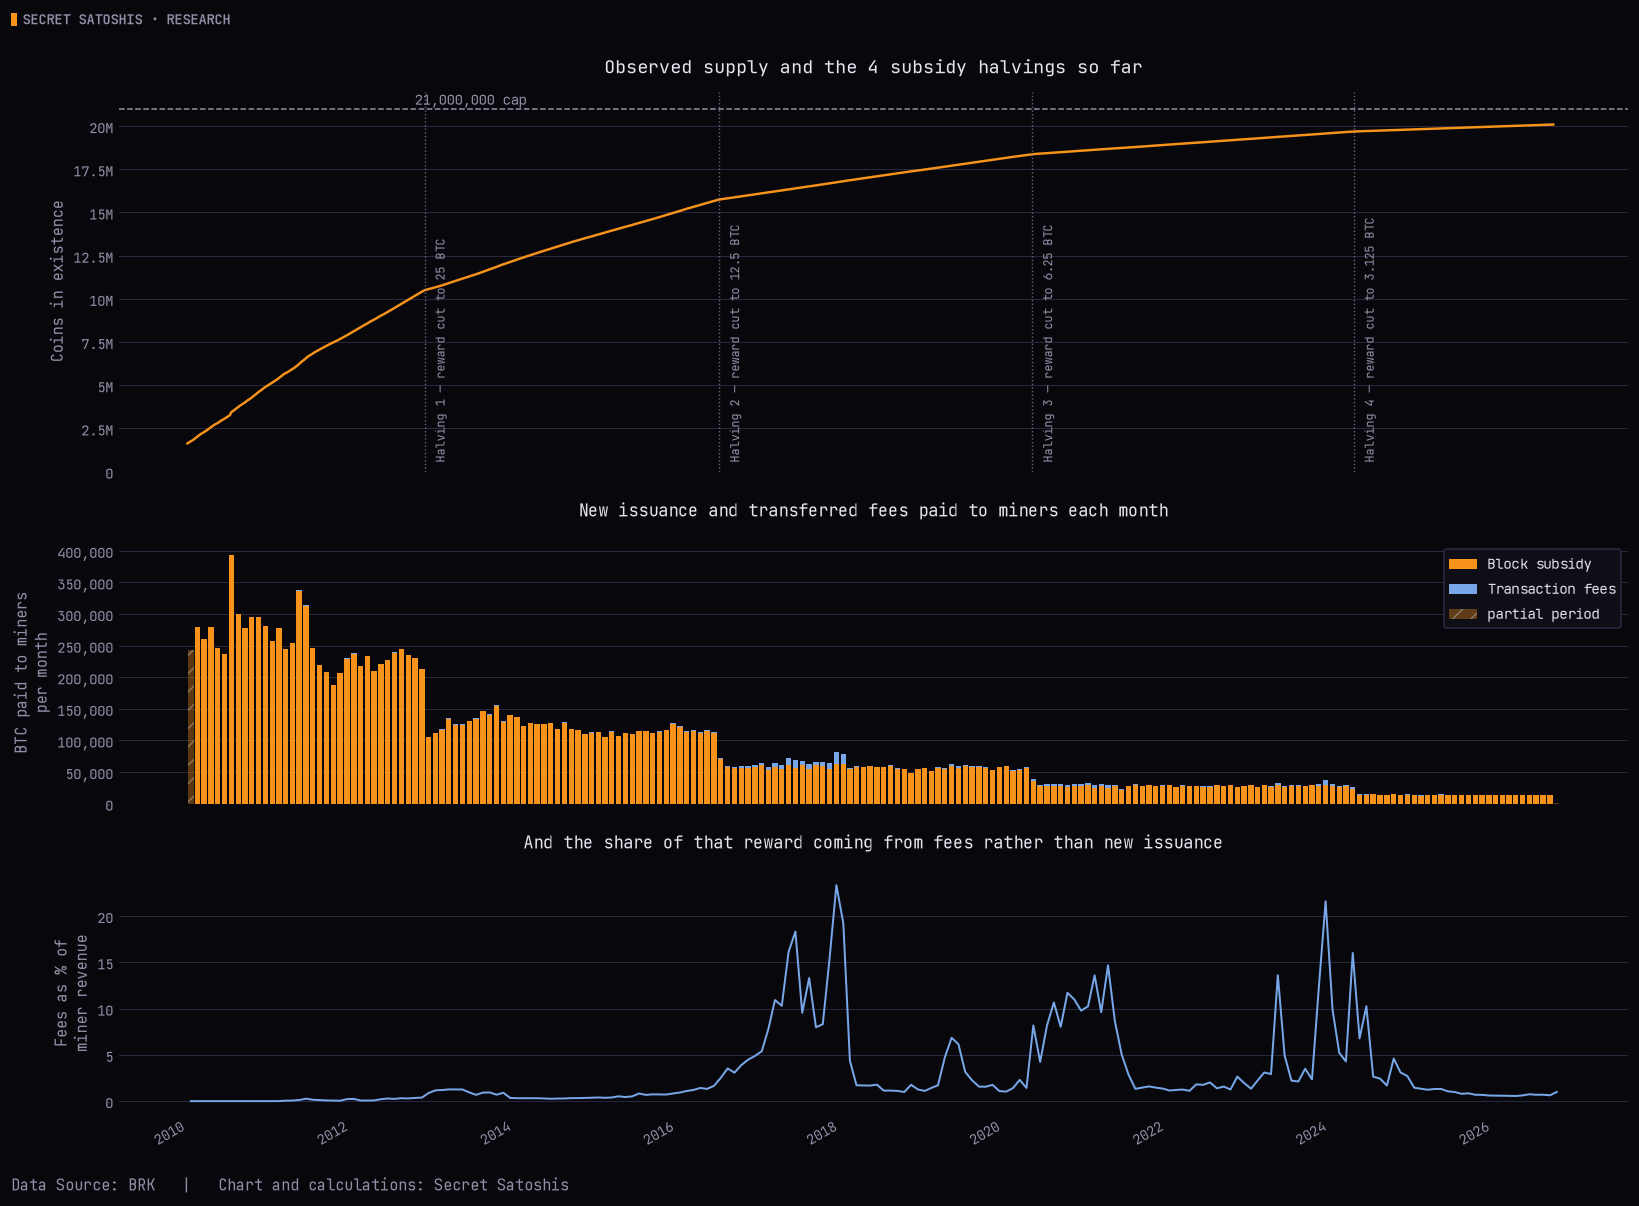

year         subsidy      fees   fee share     status
2021         329,288    21,462       6.12%   complete
2022         332,425     5,375       1.59%   complete
2023         337,494    23,432       6.49%   complete
2024         217,772    15,192       6.52%   complete
2025         165,881     1,720       1.03%   complete
2026         122,391       784       0.64%    partial

Highest fee share on record: 12.6% in 2017
New BTC issued on the latest completed day: 425.000. Fees transferred to miners: 4.246 BTC.
Subsidy rate: 3.125 BTC per block.


In [4]:
subsidy = daily["subsidy_daily"]
fees = daily["fees_daily"]
miner_revenue_btc = subsidy + fees

# Halving dates are the protocol schedule (bitcoin_investment_strategy.research.analysis),
# shared with the supply notebook and the Report Library.
halvings = halving_dates()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 11), sharex=True,
                                    gridspec_kw={"height_ratios": [1.6, 1.1, 1]})

ax1.plot(daily.index, daily["supply"], color=ORANGE, linewidth=1.6)
ax1.axhline(21e6, color=GREY, linestyle="--", linewidth=1)
ax1.annotate("21,000,000 cap", (daily.index[len(daily) // 6], 21e6), fontsize=9,
             color=GREY, va="bottom")
for n, date, reward in halvings:
    ax1.axvline(date, color=GREY, linestyle=":", linewidth=.9, alpha=.7)
    ax1.annotate(f"Halving {n} — reward cut to {reward:g} BTC", xy=(date, 0),
                 xytext=(5, 6), textcoords="offset points", rotation=90,
                 fontsize=8, color=GREY, ha="left", va="bottom")
ax1.set_ylabel("Coins in existence"); ax1.set_ylim(0, 22e6)
ax1.yaxis.set_major_formatter(FuncFormatter(compact))
ax1.set_title(f"Observed supply and the {len(halvings)} subsidy halvings so far",
              fontsize=12, pad=12)

m_sub = subsidy.resample("ME").sum(min_count=1)
m_fee = fees.resample("ME").sum(min_count=1)
centers, full = period_centers(m_sub.index, "M"), complete_periods(m_sub.index, "M")

ax2.bar(centers[full], m_sub[full], width=24, color=ORANGE, label="Block subsidy")
ax2.bar(centers[full], m_fee[full], bottom=m_sub[full], width=24, color=BLUE,
        label="Transaction fees")
ax2.bar(centers[~full], (m_sub + m_fee)[~full], width=24, color=ORANGE, alpha=.35,
        hatch="//", label="partial period")
ax2.set_ylabel("BTC paid to miners\nper month")
ax2.yaxis.set_major_formatter(FuncFormatter(thousands))
ax2.legend(fontsize=9)
ax2.set_title("New issuance and transferred fees paid to miners each month", fontsize=11)

share = m_fee / (m_sub + m_fee) * 100
ax3.plot(centers, share, color=BLUE, linewidth=1.3)
ax3.set_ylabel("Fees as % of\nminer revenue")
ax3.set_title("And the share of that reward coming from fees rather than new issuance",
              fontsize=11)
finish(fig, sources=[BRK])

by_year = pd.DataFrame({"subsidy": subsidy, "fees": fees}).resample("YE").sum(min_count=1)
by_year["complete"] = complete_periods(by_year.index, "Y")
by_year["fee share"] = by_year["fees"] / (by_year["subsidy"] + by_year["fees"]) * 100
print(f"{'year':<8}{'subsidy':>12}{'fees':>10}{'fee share':>12}{'status':>11}")
for ts, r in by_year.tail(6).iterrows():
    print(f"{ts.year:<8}{r['subsidy']:>12,.0f}{r['fees']:>10,.0f}{r['fee share']:>11.2f}%"
          f"{'complete' if r['complete'] else 'partial':>11}")
peak = by_year.loc[by_year["complete"], "fee share"].idxmax()
print(f"\nHighest fee share on record: {by_year.loc[peak, 'fee share']:.1f}% in {peak.year}")
print(f"New BTC issued on the latest completed day: {subsidy.iloc[-1]:,.3f}. "
      f"Fees transferred to miners: {fees.iloc[-1]:,.3f} BTC.")
print(f"Subsidy rate: {halvings[-1][2]:g} BTC per block.")

### How block production is regulated

The protocol aims for a block every ten minutes, but it has no way to enforce that. Nothing stops miners from finding blocks faster.

So it checks its own work. Every 2,016 blocks it looks at how long that batch actually took. If the blocks came faster than ten minutes apart, difficulty goes up and the next batch is harder. If they came slower, difficulty comes down.

The consequence matters for everything that follows: more hashpower does not permanently produce more coins. It produces higher difficulty.

The first panel shows difficulty. The second shows the realized minutes per block in each complete period, against the ten-minute target.

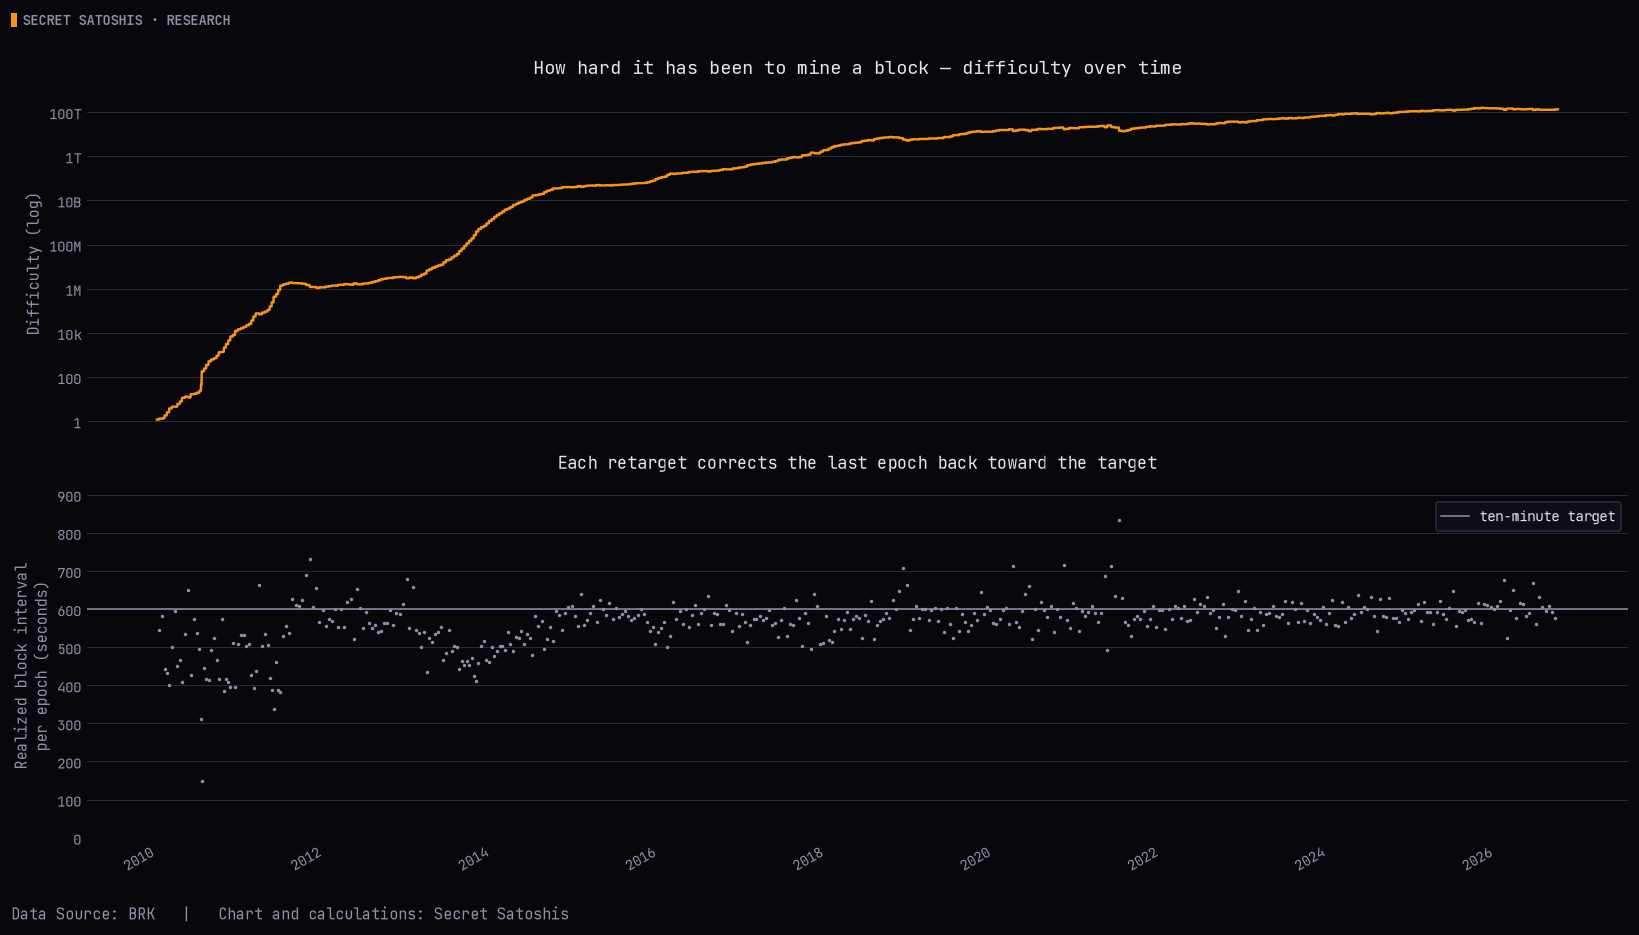

retargets observed                 465
median realized interval          574s
largest upward retarget        +300.0%   2010-07-16
largest downward retarget       -27.9%   2021-07-03

The median inferred epoch interval was 26s per block faster than target.
This statistic combines stochastic timing and hashpower changes within retarget periods.


In [5]:
difficulty = daily["difficulty"].dropna()

# Difficulty only changes at a retarget, so the change points are the epochs.
# The protocol sets next_difficulty = difficulty x (target time / actual time),
# which means the ratio between consecutive values recovers the realized block
# interval — no block-timestamp data required.
retargets = difficulty[difficulty.diff() != 0]
step = (retargets / retargets.shift(1)).dropna()
interval = 600 / step

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8.5), sharex=True)

ax1.plot(difficulty.index, difficulty, color=ORANGE, linewidth=1.6)
ax1.set_yscale("log"); ax1.set_ylabel("Difficulty (log)")
ax1.yaxis.set_major_formatter(FuncFormatter(compact))
ax1.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: ""))
ax1.set_title("How hard it has been to mine a block — difficulty over time",
              fontsize=12, pad=12)

ax2.plot(interval.index, interval, color=GREY, linewidth=.9, marker=".", markersize=2.5,
         linestyle="none")
ax2.axhline(600, color=GREY, linewidth=1, label="ten-minute target")
ax2.set_ylabel("Realized block interval\nper epoch (seconds)"); ax2.set_ylim(0, 900)
ax2.legend(fontsize=9)
ax2.set_title("Each retarget corrects the last epoch back toward the target", fontsize=11)
finish(fig, sources=[BRK])

pct = (step - 1) * 100
print(f"{'retargets observed':<28}{len(retargets):>10,}")
print(f"{'median realized interval':<28}{interval.median():>9,.0f}s")
print(f"{'largest upward retarget':<28}{pct.max():>+9.1f}%   {pct.idxmax().date()}")
print(f"{'largest downward retarget':<28}{pct.min():>+9.1f}%   {pct.idxmin().date()}")
delta = 600 - interval.median()
print(f"\nThe median inferred epoch interval was {abs(delta):.0f}s per block "
      f"{'faster' if delta >= 0 else 'slower'} than target.")
print("This statistic combines stochastic timing and hashpower changes within retarget periods.")

### The scale of computational work

Nobody meters the network. Hashrate is worked out backwards — from how hard the problem was and how quickly blocks were being found. It is a good estimate, not a reading off a dial.

The series runs across four eras of hardware: CPUs, then GPUs, then FPGAs, then chips built for nothing else. Two later markers show shifts in where mining happens rather than what it runs on: industrial-scale sites, and the 2021 move out of China. The labels mark roughly when each began, not the day it did.

Price and hashrate move together, and it is worth being careful about why. A higher price makes mining pay, which pulls in machines — but machines take months to order and install, and difficulty then absorbs whatever shows up. Each side feeds the other through a chain of delays. When one appears to lead on a chart, that describes a period; it is not a rule to hold onto.

The first panel puts hashrate next to price. The second compares their ninety-day changes, which shows the timing without pretending the lag is fixed.

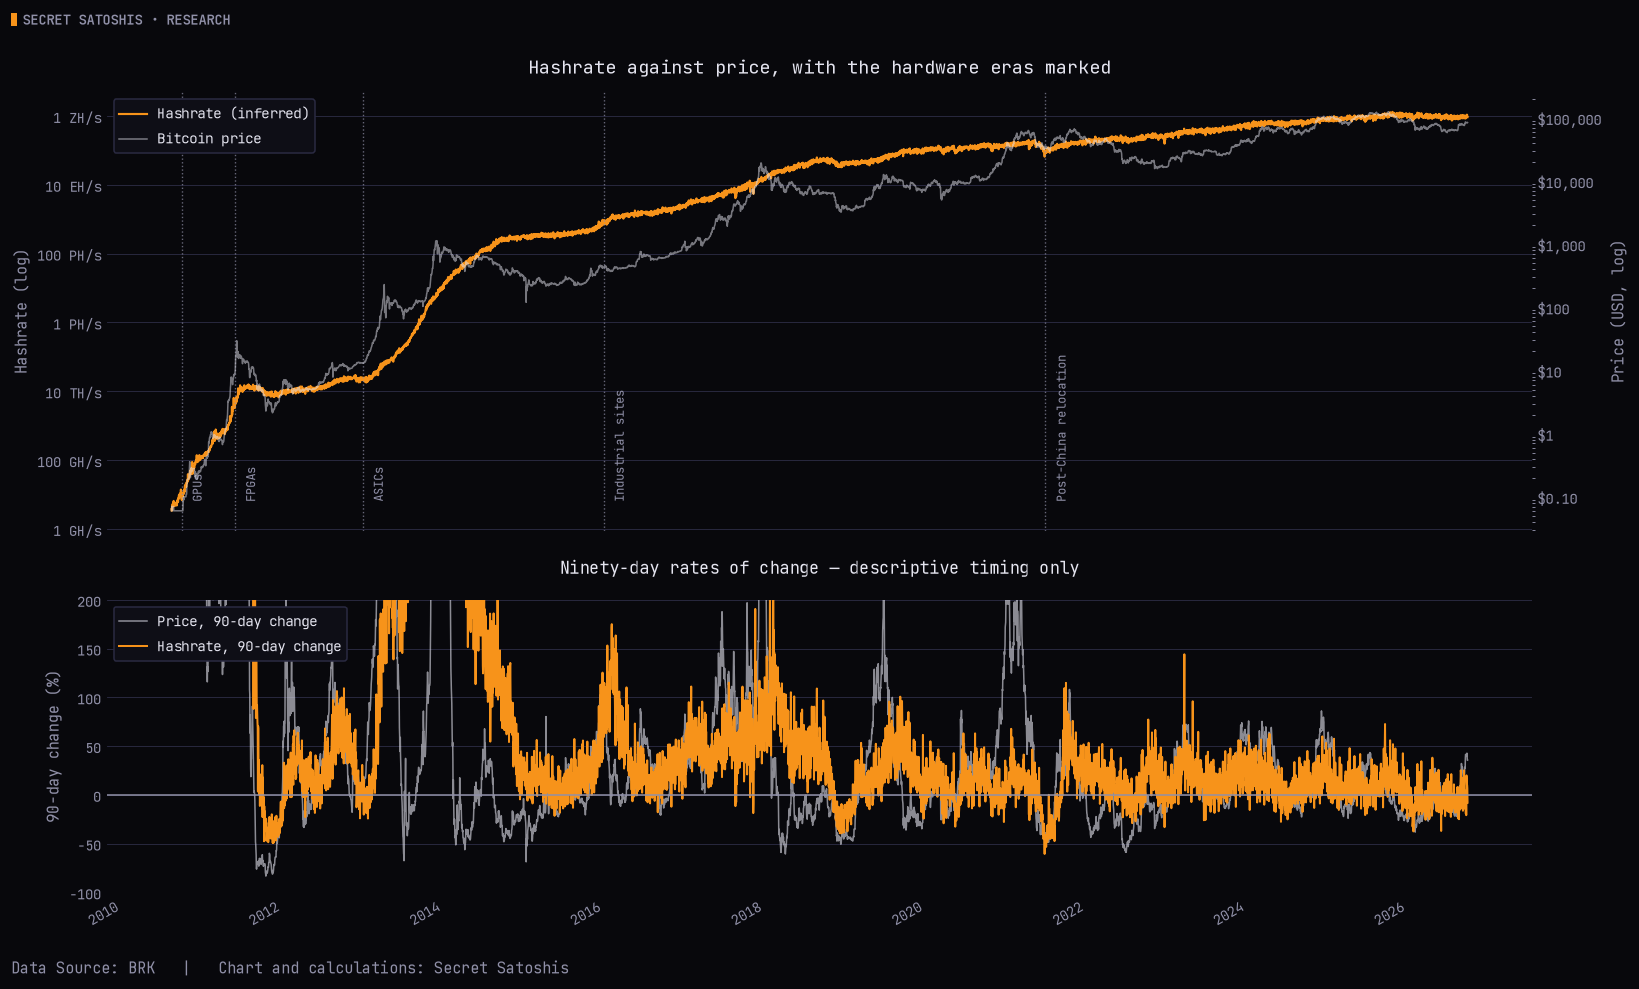

Hashrate has grown from about 171,701,943 hashes per second in 2010 to 9.24e+20 today —
a factor of 5.4e+12, or 13 orders of magnitude.

hashrate trough     90d hashrate   90d price into it
2011-11-19                  -49%                -81%
2013-01-25                  -24%                 69%
2015-05-23                  -22%                  1%
2016-09-03                  -18%                  4%
2017-11-11                  -19%                 57%
2018-12-11                  -40%                -47%
2021-06-27                  -61%                -43%
2022-12-24                  -33%                -11%
2023-06-21                  -26%                  6%
2024-06-05                  -28%                  6%
2025-06-23                  -21%                 20%
2026-01-28                  -38%                -17%


In [6]:
hashrate = priced["hash_rate"]

# Approximate start of each hardware era. Marked to show that the growth in
# hashrate is not one trend but a sequence of step changes in what a "miner" is.
ERAS = [("2010-10-01", "GPUs"), ("2011-06-01", "FPGAs"), ("2013-01-01", "ASICs"),
        ("2016-01-01", "Industrial sites"), ("2021-07-01", "Post-China relocation")]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                               gridspec_kw={"height_ratios": [1.5, 1]})

ax1.plot(hashrate.index, hashrate, color=ORANGE, linewidth=1.4, label="Hashrate (inferred)")
for when, label in ERAS:
    when = pd.Timestamp(when)
    if when < hashrate.index.min():
        continue
    ax1.axvline(when, color=GREY, linestyle=":", linewidth=.9, alpha=.7)
    ax1.annotate(label, xy=(when, hashrate.min()), xytext=(5, 6),
                 textcoords="offset points", rotation=90, fontsize=8,
                 color=GREY, ha="left", va="bottom")
ax1.set_yscale("log"); ax1.set_ylabel("Hashrate (log)")
log_axis(ax1.yaxis, hashes)

px = ax1.twinx()
px.plot(priced.index, priced["price"], color=PRIMARY, linewidth=1, alpha=.5, label="Bitcoin price")
price_axis(px, "Price (USD, log)"); px.grid(False)

bars, names = ax1.get_legend_handles_labels()
line, lname = px.get_legend_handles_labels()
ax1.legend(bars + line, names + lname, fontsize=9, loc="upper left")
ax1.set_title("Hashrate against price, with the hardware eras marked", fontsize=12, pad=12)

# Compare 90-day rates of change as a timing diagnostic. The chart does not
# estimate a causal or stable lead-lag relationship.
ax2.plot(priced.index, priced["price"].pct_change(90) * 100, color=PRIMARY, linewidth=1,
         alpha=.6, label="Price, 90-day change")
ax2.plot(hashrate.index, hashrate.pct_change(90) * 100, color=ORANGE, linewidth=1.3,
         label="Hashrate, 90-day change")
ax2.axhline(0, color=GREY, linewidth=1)
ax2.set_ylabel("90-day change (%)"); ax2.set_ylim(-100, 200)
ax2.legend(fontsize=9, loc="upper left")
ax2.set_title("Ninety-day rates of change — descriptive timing only", fontsize=11)
finish(fig, sources=[BRK])

# Measured from the full record, not the priced window: the record's first year
# is CPU mining before the first exchange price, and it is the interesting end.
FIRST_YEAR = daily.index[0].year
first_year = daily["hash_rate"][daily.index.year == FIRST_YEAR].median()
print(f"Hashrate has grown from about {first_year:,.0f} hashes per second in {FIRST_YEAR} "
      f"to {hashrate.iloc[-1]:.3g} today —")
print(f"a factor of {hashrate.iloc[-1] / first_year:.1e}, or {np.log10(hashrate.iloc[-1] / first_year):.0f} "
      "orders of magnitude.\n")

# The deepest hashrate drawdowns, and what price had already done going in.
h90 = hashrate.pct_change(90) * 100
worst = h90.nsmallest(400).sort_index()
groups = (worst.index.to_series().diff().dt.days.fillna(999) > 120).cumsum()
print(f"{'hashrate trough':<18}{'90d hashrate':>14}{'90d price into it':>20}")
for _, g in worst.groupby(groups):
    day = g.idxmin()
    print(f"{str(day.date()):<18}{g.min():>13.0f}%{priced['price'].pct_change(90).loc[day] * 100:>19.0f}%")

### Estimated electricity expense per BTC earned

Electricity is the largest input a miner has to keep buying. Put together the estimated hashrate, the estimated efficiency of the fleet, a price for power, and the coins actually paid out, and you get an estimate of what the average coin cost in electricity alone.

```
   power drawn    =  hashrate  ×  hardware efficiency
   power expense per BTC earned  =  energy  ×  electricity price  ÷  (subsidy + fees)
```

**Fleet efficiency** is an average across the whole network, which means it describes nobody in particular. 

**Electricity price** varies more than anything else here. A hydro site on a long contract and a gas plant buying at spot compete against each other while paying wildly different amounts for the same joule.

And the result is not the cost of mining. It leaves out hardware, replacement cycles, staff, buildings, cooling, financing, taxes and pool fees. It is one input priced across a range of assumptions — useful for judging scale and stress, and not a break-even price for anybody.

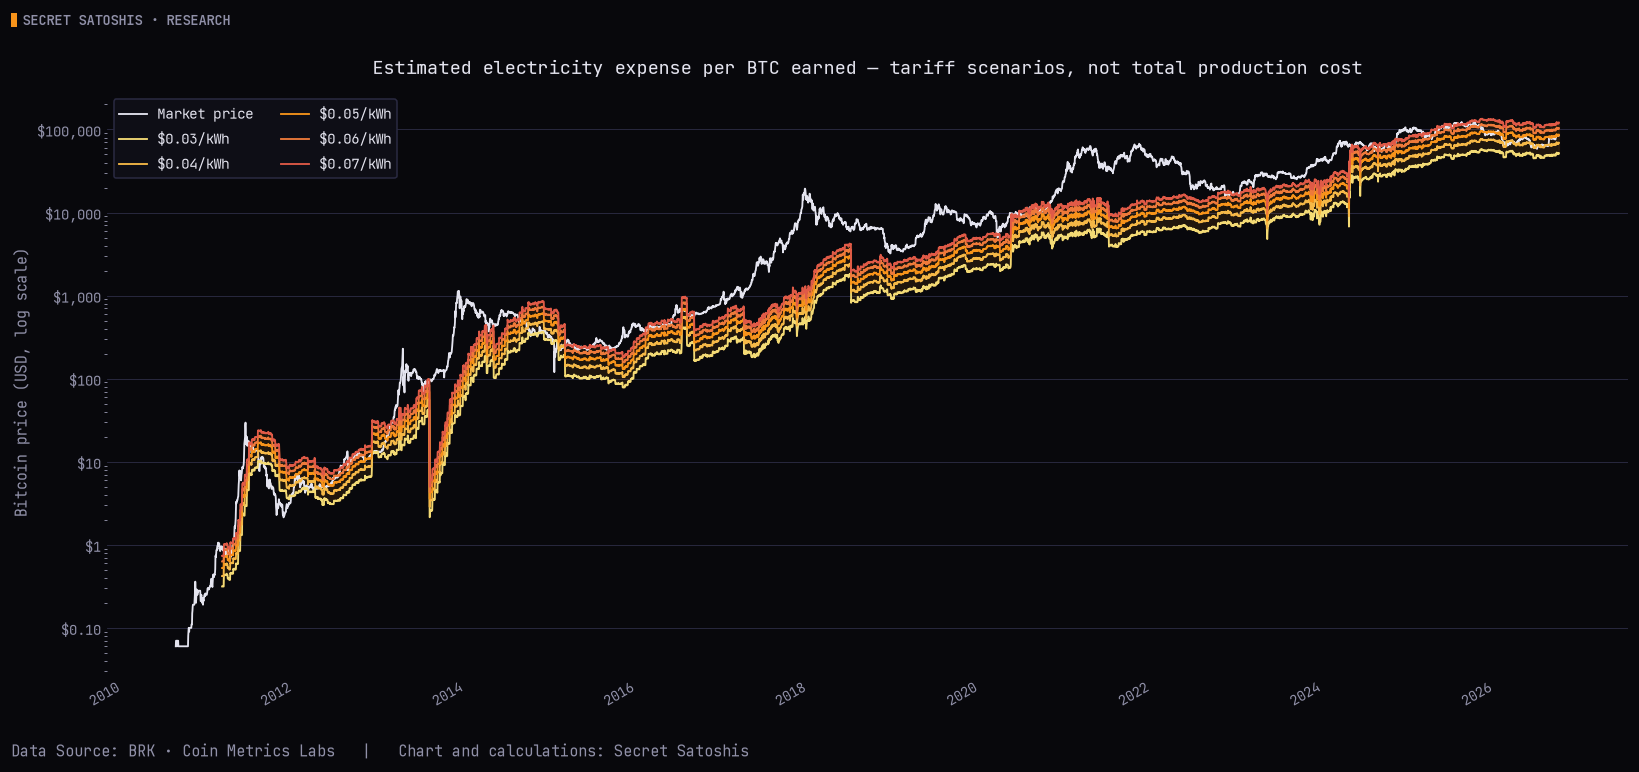

electricity      cost per coin
$0.03/kWh              51,949
$0.04/kWh              69,265
$0.05/kWh              86,581
$0.06/kWh             103,898
$0.07/kWh             121,214
market price           84,572

Network draw today: 31.0 GW at 0.0335 J/GH
Power-only break-even tariff: $0.0488/kWh before hardware, financing, cooling, facilities and other operating costs.


In [7]:
TARIFFS = [0.03, 0.04, 0.05, 0.06, 0.07]

# Fleet power draw, then the daily electricity bill, then dollars per BTC
# of miner revenue. This excludes hardware, financing and non-power expenses.
power_watts = daily["hash_rate"] / 1e9 * daily["cm_efficiency_j_gh"]
kwh_per_day = power_watts * 24 / 1000
cost = pd.DataFrame({f"${t:.2f}/kWh": (kwh_per_day * t) / miner_revenue_btc
                     for t in TARIFFS}).loc[FIRST_PRICE:]

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(priced.index, priced["price"], color=PRIMARY, linewidth=1.2, label="Market price")
# Cheapest tariff to dearest, light to dark along the brand's warm ramp.
ramp = ["#F3DA75", "#F5B847", ORANGE, "#EE7A3A", "#E05A47"]
for col, color in zip(cost.columns, ramp):
    ax.plot(cost.index, cost[col], color=color, linewidth=1.2, label=col)
ax.fill_between(cost.index, cost.iloc[:, 0], cost.iloc[:, -1], color=ORANGE, alpha=.10)
price_axis(ax)
ax.legend(fontsize=9, loc="upper left", ncol=2)
finish(fig, "Estimated electricity expense per BTC earned — tariff scenarios, not total production cost", ax, sources=[BRK, COIN_METRICS])

print(f"{'electricity':<14}{'cost per coin':>16}")
for col in cost.columns:
    print(f"{col:<14}{cost[col].iloc[-1]:>15,.0f}")
print(f"{'market price':<14}{priced['price'].iloc[-1]:>15,.0f}")

breakeven = priced["price"].iloc[-1] / (kwh_per_day.iloc[-1] / miner_revenue_btc.iloc[-1])
print(f"\nNetwork draw today: {power_watts.iloc[-1] / 1e9:.1f} GW at "
      f"{daily['cm_efficiency_j_gh'].iloc[-1]:.4f} J/GH")
print(f"Power-only break-even tariff: ${breakeven:.4f}/kWh before hardware, "
      "financing, cooling, facilities and other operating costs.")

### How miners adapt

When the coins a machine earns stop covering the power it burns, the machine gets switched off — eventually.

If enough machines go dark, blocks slow down and the next adjustment lowers difficulty. The miners still running then earn the same coins for less work, so the electricity per coin falls. The cost came down to meet the price rather than the price rising to meet the cost.

That is why the estimate above cannot be a floor. Price, fees, difficulty, efficiency and the number of machines plugged in all move each other around. There is no fixed number underneath holding anything up.

The first panel puts price against the power-expense scenarios. The second shows the thirty- and sixty-day averages of hashrate, the standard way of watching the fleet contract. A crossover means the recent average has dropped below the longer one. It is a smoothed signal about hashpower, not a count of machines unplugged, and it is not tested here as a way to trade.

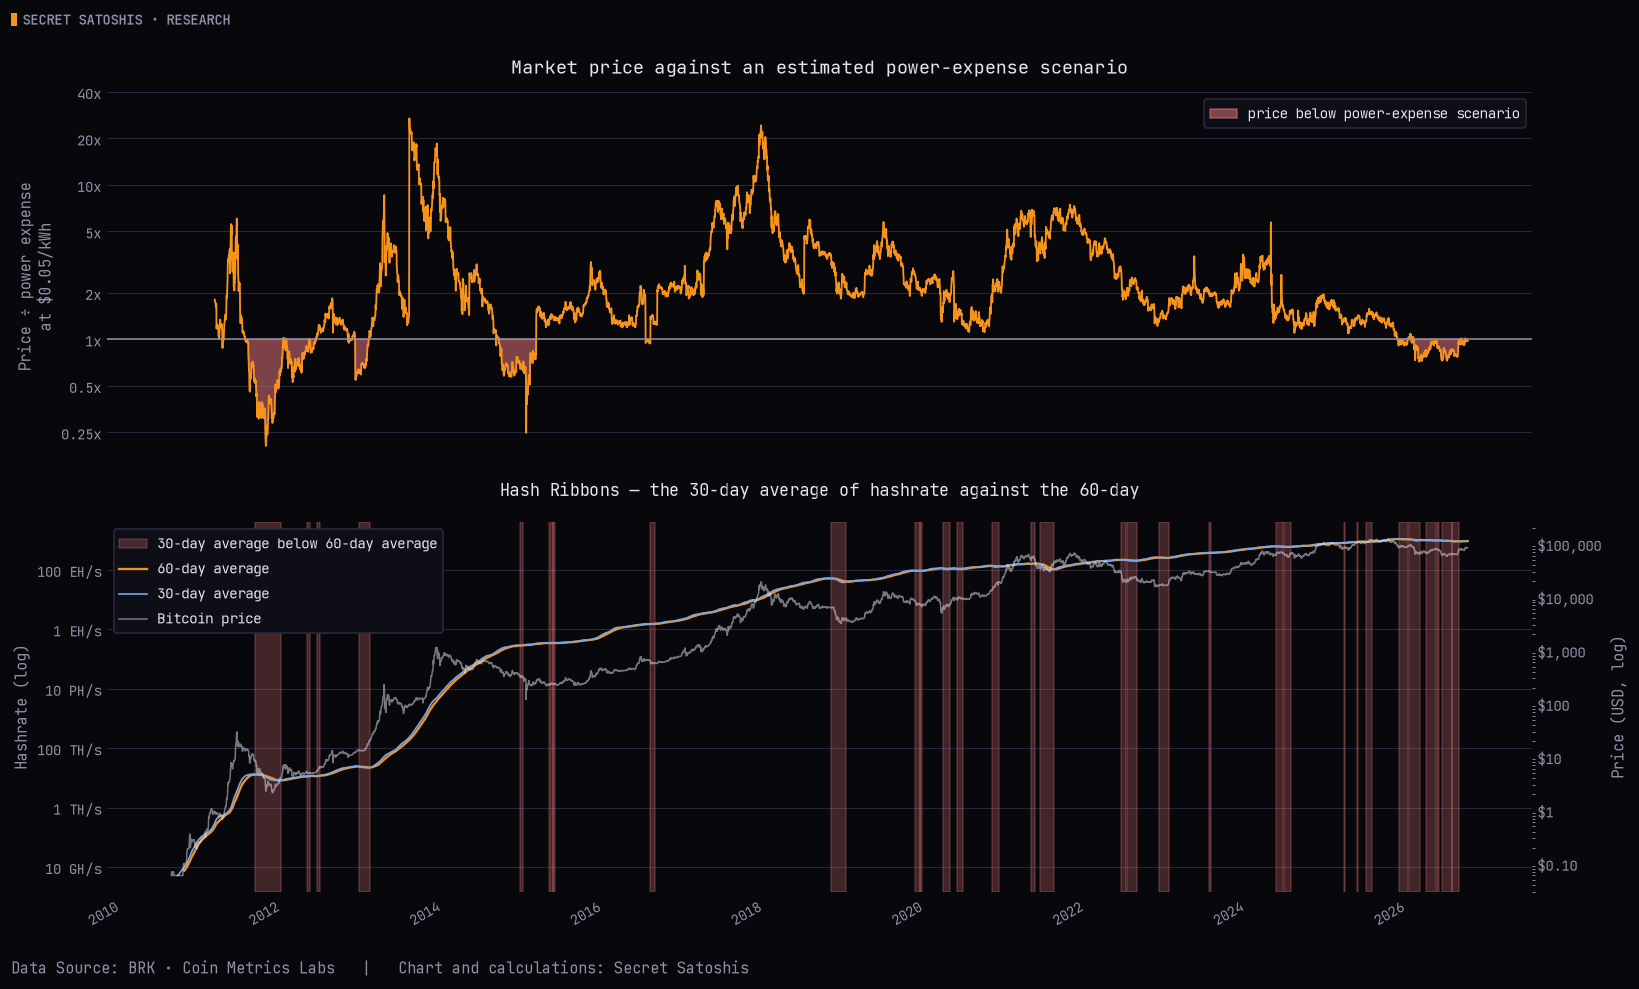

Price sat below the $0.05/kWh power-expense scenario on 872 of 5,694 days (15.3%)

episode                     days   lowest  difficulty after 90d
2011-04-05 to 2011-04-10       6    0.88x               +1798%
2011-07-18 to 2012-06-03     311    0.20x                 +53%
2012-10-26 to 2013-01-28      72    0.55x                +202%
2014-08-31 to 2015-02-28     170    0.25x                  +5%
2016-07-10 to 2016-07-31      21    0.94x                 +19%
2025-11-17 to 2026-10-01     292    0.72x           still open

Latest completed day: price is 0.98x the $0.05/kWh power-expense scenario (below the 1x line).

The 30-day average was below the 60-day average on 1,023 of 5,832 valid days (18%), across 32 spells of five days or more.
Right now the 30-day average sits at 1.023 of the 60-day.


In [8]:
MID = "$0.05/kWh"
ratio = (priced["price"] / cost[MID]).dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax1.plot(ratio.index, ratio, color=ORANGE, linewidth=1.2)
ax1.fill_between(ratio.index, 1, ratio, where=ratio < 1, color=RED, alpha=.5,
                 label="price below power-expense scenario")
ax1.axhline(1, color=GREY, linewidth=1)
ax1.set_yscale("log"); ax1.set_ylabel(f"Price ÷ power expense\nat {MID}")
ax1.set_yticks([0.25, 0.5, 1, 2, 5, 10, 20, 40]); ax1.minorticks_off()
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}x"))
ax1.legend(fontsize=9, loc="upper right")
ax1.set_title("Market price against an estimated power-expense scenario",
              fontsize=12, pad=12)

# Hash Ribbons: the 30- and 60-day moving averages of inferred hashrate. A
# crossover is a smoothed contraction signal, not direct machine-level evidence.
fast = hashrate.rolling(30).mean()
slow = hashrate.rolling(60).mean()
capitulation = fast < slow

# The two averages run about 1% apart, which is invisible against fourteen
# orders of magnitude of growth. So the periods where the fast one is below the
# slow one are marked as vertical bands instead of shaded between the lines.
runs = (capitulation != capitulation.shift()).cumsum()
spells = [v for _, v in capitulation.groupby(runs) if v.iloc[0] and len(v) >= 5]
for n, spell in enumerate(spells):
    ax2.axvspan(spell.index.min(), spell.index.max(), color=RED, alpha=.25,
                label="30-day average below 60-day average" if n == 0 else None)

ax2.plot(slow.index, slow, color=ORANGE, linewidth=1.5, label="60-day average")
ax2.plot(fast.index, fast, color=BLUE, linewidth=1.1, label="30-day average")
ax2.set_yscale("log"); ax2.set_ylabel("Hashrate (log)")
log_axis(ax2.yaxis, hashes)

# Price behind the ribbon, so the capitulation bands can be read against what
# the coin was doing at the time.
px2 = ax2.twinx()
px2.plot(priced.index, priced["price"], color=PRIMARY, linewidth=1, alpha=.5,
         label="Bitcoin price")
price_axis(px2, "Price (USD, log)"); px2.grid(False)

lines, names = ax2.get_legend_handles_labels()
pl, pn = px2.get_legend_handles_labels()
ax2.legend(lines + pl, names + pn, fontsize=9, loc="upper left")
ax2.set_title("Hash Ribbons — the 30-day average of hashrate against the 60-day", fontsize=11)
finish(fig, sources=[BRK, COIN_METRICS])

below = ratio[ratio < 1]
episodes = (below.index.to_series().diff().dt.days.fillna(999) > 30).cumsum()
print(f"Price sat below the {MID} power-expense scenario on {len(below):,} of "
      f"{len(ratio):,} days ({len(below) / len(ratio) * 100:.1f}%)\n")
print(f"{'episode':<26}{'days':>6}{'lowest':>9}{'difficulty after 90d':>22}")
for _, e in below.groupby(episodes):
    start, end = e.index.min(), e.index.max()
    move = forward_change(difficulty, end, LAST_DAY, days=90)
    print(f"{str(start.date()) + ' to ' + str(end.date()):<26}{len(e):>6}{e.min():>8.2f}x{move:>21}")
state = "below" if ratio.iloc[-1] < 1 else "above"
print(f"\nLatest completed day: price is {ratio.iloc[-1]:.2f}x the {MID} "
      f"power-expense scenario ({state} the 1x line).")

ribbon_valid = fast.notna() & slow.notna()
print(f"\nThe 30-day average was below the 60-day average on "
      f"{capitulation[ribbon_valid].sum():,} of {ribbon_valid.sum():,} valid days "
      f"({capitulation[ribbon_valid].mean() * 100:.0f}%), across "
      f"{len(spells)} spells of five days or more.")
print(f"Right now the 30-day average sits at {fast.iloc[-1] / slow.iloc[-1]:.3f} of the 60-day.")

### What mining can tell us

Miners are buyers. They spend hardware, electricity, staff and financing to acquire coins, and they commit all of it before knowing whether they will get any. Nobody makes them publish a thing, and yet this is the only group in the notebook whose purchase price we can estimate from the outside — because the protocol writes down how much work went in and exactly what came out.

Three things follow.

**The coins arrive on a schedule, however hard anyone bids.** More hashpower makes blocks come faster for a few days; then difficulty rises and the rate settles back toward ten minutes.

**What miners pay is a scenario, not a measurement.** Nobody meters any of this: hashrate is inferred, fleet efficiency is modeled, and every miner buys power on different terms. It is also electricity only, with no hardware, staff or financing in it.

**And the cost is not a floor.** The preceding output reports how often price falls below the five-cent scenario over valid observations in this release. That is possible because the cost adjusts: when revenue stops covering the power bill, machines switch off, difficulty falls at the next retarget, and the electricity per coin drops to meet the price.

So mining hands us one group of buyers with a price attached. What it cannot hand us is anybody else. It says nothing about who bought the coins those miners sold, what they paid, or whether the coins were bought at all rather than moved between two accounts of the same owner. For that we have to leave the part of the record the protocol guarantees — starting with the most abundant evidence available, and the hardest to read.

---

# 2. Everyone else: how many people hold bitcoin?

Every coin that changes hands after issuance already exists. It moves from one output to another, and the chain records the move exactly: which coins, which addresses, what time, what fee. It does not record why. On the ledger a purchase is indistinguishable from a wallet upgrade, a deposit to an exchange, a transfer between two accounts belonging to the same person, or collateral posted against a loan.

So the chain cannot count buyers. What it can count is addresses holding a balance — as long as we say precisely what balance we mean.

An address is not a person, and not even a durable account. One person can spread coins across a hundred addresses in an afternoon. One exchange can hold coins for a million people in a handful of them. The count moves when wallet software changes its defaults, when fees make small outputs uneconomic to spend, and when people hand their coins to a custodian who keeps them all under one roof.

That makes an address count a proxy, and a proxy that drifts. The panels below count four ways — any balance at all, then 0.001 BTC and up, 0.01 and up, 0.1 and up — because a threshold that ignores dust behaves differently from one that counts it. Where all four move together we are seeing something real about the ledger. None of them is a headcount.

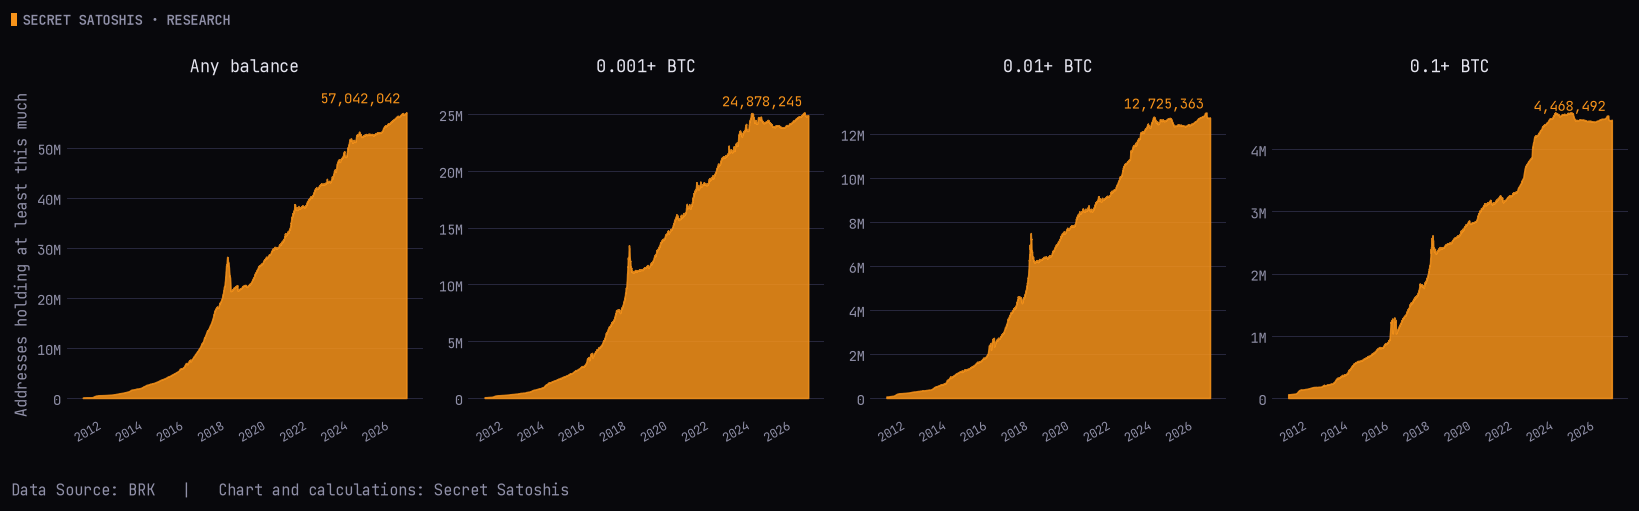

definition               today   2013-20 a year   2020-25 a year
Any balance         57,042,042           45.8%           10.8%
0.001+ BTC          24,878,245           46.3%            7.8%
0.01+ BTC           12,725,363           39.8%            8.1%
0.1+ BTC             4,468,492           31.4%            7.4%

Addresses holding 0.001+ BTC fell from 25,094,201 to 23,886,466 during 2024 (-4.8%).


In [9]:
BANDS = {"non_zero_addr_count": "Any balance",
         "addr_count_over_0p001_btc": "0.001+ BTC",
         "addr_count_over_0p01_btc": "0.01+ BTC",
         "addr_count_over_0p1_btc": "0.1+ BTC"}

# From 2011: before that the whole network is a few thousand addresses and every
# definition gives the same line.
addr = daily[list(BANDS)].dropna().loc["2011":]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.6), sharex=True)
for ax, (col, label) in zip(axes, BANDS.items()):
    s = addr[col]
    ax.fill_between(s.index, 0, s, color=ORANGE, alpha=.85)
    ax.set_title(label, fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.tick_params(axis="x", labelsize=8)
    ax.annotate(f"{s.iloc[-1]:,.0f}", xy=(s.index[-1], s.iloc[-1]), xytext=(-4, 6),
                textcoords="offset points", ha="right", fontsize=9, color=ORANGE)
axes[0].set_ylabel("Addresses holding at least this much")
finish(fig, sources=[BRK])

print(f"{'definition':<16}{'today':>14}{'2013-20 a year':>17}{'2020-25 a year':>17}")
for col, label in BANDS.items():
    s = addr[col]
    a, b, c = (s[s.index.year == y].iloc[-1] for y in (2013, 2020, 2025))
    print(f"{label:<16}{s.iloc[-1]:>14,.0f}{(b / a) ** (1 / 7) - 1:>16.1%}{(c / b) ** (1 / 5) - 1:>16.1%}")

peak = addr["addr_count_over_0p001_btc"]
y23, y24 = (peak[peak.index.year == y].iloc[-1] for y in (2023, 2024))
print(f"\nAddresses holding 0.001+ BTC {'fell' if y24 < y23 else 'rose'} from {y23:,.0f} to {y24:,.0f} during 2024 "
      f"({(y24 / y23 - 1) * 100:+.1f}%).")

### What the market paid, on average

Counting addresses says nothing about price. But the chain does record a price of a sort — not the price anyone agreed on, but the market price on the day each coin last moved.

Value every unspent output at the price on the day it was created, add them up, and you have realized capitalization. Divide by supply and you have **realized price**: a per-coin average of the whole ledger's last-movement prices.

It is tempting to call this what holders paid. It is not, for four reasons, and each one bites.

Moving coins between your own wallets reprices them at today's price without a purchase happening. Trading on an exchange changes owners without moving coins, so the chain never sees the price. Coins lost in 2011 still carry 2011 prices and always will. And the chain does not know which outputs belong to the same person, so this is an average across outputs, not across people.

What it does support is a comparison. Price above realized price means the average coin last moved cheaper than it trades today — a fact about coins, not a count of people in profit. The supply notebook charts realized price against market price over the full history (its section 6); here it is kept as one number, for the comparison in section 5.

In [10]:
# Realized price is charted in the supply notebook; here it is one of the price-like
# measures compared in section 5. It reads exactly zero for the first weeks of trading,
# below the provider's precision, so those days are dropped.
rp = daily["realized_price"].reindex(priced.index)
rp = rp[rp > 0]
print(f"Realized price at cutoff: ${rp.iloc[-1]:,.0f}, against a market price of "
      f"${priced['price'].iloc[-1]:,.0f} ({priced['price'].iloc[-1] / rp.iloc[-1]:.2f}x).")

Realized price at cutoff: $53,610, against a market price of $84,572 (1.58x).


### How many owners there actually are

Neither addresses nor realized price counts people. To get a headcount at all you have to leave the chain and take someone's estimate, which trades one problem for another. The chain's numbers are exact and measure something other than what we want. A survey measures the right thing and is not exact.

The owner series here is Crypto.com's market sizing — a model built on exchange data and regional assumptions, not an audited census or a probability sample, and its earliest years are back-filled assumptions documented in the source table. Read it as scale: right order of magnitude, wrong in the decimals.

Set beside it is internet adoption. That is not a claim that the two technologies spread the same way. It is a reference for what an adoption curve looks like when somebody measured one all the way through.

The left panel plots the series in calendar time. The right shifts internet use and funded addresses to their first observed crossing of 0.05% of world population. The output identifies those crossing years from the loaded data.

Owner estimates begin after that threshold was already exceeded, so their crossing is not observed. They borrow the address-series anchor and are drawn dashed. This is a comparison of proxies with different definitions, not a measured common adoption clock. The summary uses the latest year shared by owner estimates, funded addresses and population data.


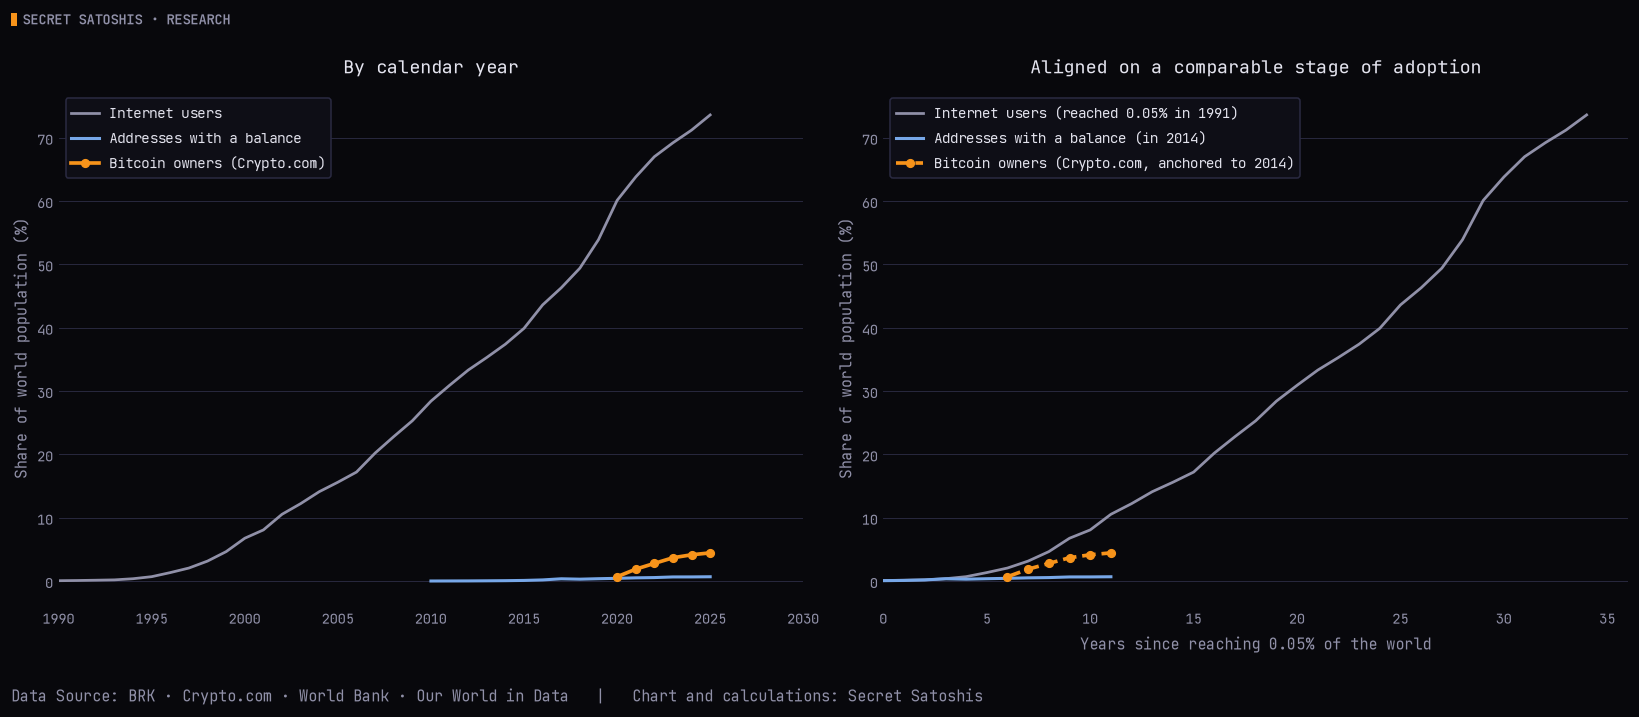

Anchored at 0.05% of world population — the internet in 1991, bitcoin in 2014. The owner estimate is placed on bitcoin's anchor.

years past that point             11
internet at the same stage    10.54%
bitcoin, owner estimate        4.44%
bitcoin, addresses             0.67%

At the same stage, internet-user share was 2.4x the owner estimate and 16x the funded-address share.
The two ways of counting bitcoin differ from each other by 6.6x.
These are recorded series, not equivalent people.

Adoption comparison year: 2025; source definitions differ.


In [11]:
adopt = adoption.set_index("Year")
pop = adopt["global_population"]
internet = (adopt["Internet users"] / pop * 100).dropna()

own = owners.set_index("year")["bitcoin_owners_millions"] * 1e6
btc_share = (own / pop.reindex(own.index) * 100).dropna()

annual_addr = daily["non_zero_addr_count"].resample("YE").last()
annual_addr.index = annual_addr.index.year
addr_share = (annual_addr / pop.reindex(annual_addr.index) * 100).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# Left: calendar time, which shows how much later bitcoin started.
ax1.plot(internet.index, internet, color=GREY, linewidth=1.8, label="Internet users")
ax1.plot(addr_share.index, addr_share, color=BLUE, linewidth=2,
         label="Addresses with a balance")
ax1.plot(btc_share.index, btc_share, color=ORANGE, linewidth=2.4, marker="o", markersize=5,
         label="Bitcoin owners (Crypto.com)")
ax1.set_ylabel("Share of world population (%)"); ax1.set_xlim(1990, 2030)
ax1.legend(fontsize=9, loc="upper left")
ax1.set_title("By calendar year", fontsize=12, pad=12)

# Right: aligned on a comparable stage rather than on first data. The internet
# series begins in 1990 already carrying 2.6 million users — measurement started
# about two decades after the network did — so anchoring both at their first data
# point would compare bitcoin's birth against an internet already well underway.
# Instead each series is shifted to the year it first reached the same share of
# the world population.
THRESHOLD = 0.05          # per cent of world population

def from_stage(series):
    start = series[series >= THRESHOLD].index.min()
    return pd.Series(series.values, index=series.index - start), start

net_al, net_from = from_stage(internet)
addr_al, addr_from = from_stage(addr_share)
ax2.plot(net_al.index, net_al.values, color=GREY, linewidth=1.8,
         label=f"Internet users (reached {THRESHOLD}% in {net_from})")
ax2.plot(addr_al.index, addr_al.values, color=BLUE, linewidth=2,
         label=f"Addresses with a balance (in {addr_from})")

# The owner estimate cannot supply its own crossing year: it opens in 2020 already
# reporting well over the threshold, so the year it actually crossed is before the
# data starts. It is placed on bitcoin's clock instead — shifted by the same year
# the address series crossed — and drawn dashed because that anchor is borrowed
# rather than observed.
assert btc_share.iloc[0] > THRESHOLD, "owner series starts below the threshold; anchor it directly"
own_al = pd.Series(btc_share.values, index=btc_share.index - addr_from)
ax2.plot(own_al.index, own_al.values, color=ORANGE, linewidth=2.4, linestyle="--",
         marker="o", markersize=5,
         label=f"Bitcoin owners (Crypto.com, anchored to {addr_from})")
ax2.set_xlabel(f"Years since reaching {THRESHOLD}% of the world")
ax2.set_ylabel("Share of world population (%)")
ax2.set_xlim(0, 36)
ax2.legend(fontsize=9, loc="upper left")
ax2.set_title("Aligned on a comparable stage of adoption", fontsize=12, pad=12)
finish(fig, sources=[BRK, CRYPTO_COM, WORLD_BANK, OWID])

common_years = btc_share.index.intersection(addr_share.index)
if common_years.empty:
    raise ValueError("Owner and address shares have no common year")
comparison_year = common_years.max()
age = comparison_year - addr_from
owner_at_age = own_al.loc[age]
address_at_age = addr_al.loc[age]
net_at_age = net_al.reindex([age]).iloc[0]
print(f"Anchored at {THRESHOLD}% of world population — the internet in {net_from}, "
      f"bitcoin in {addr_from}. The owner estimate is placed on bitcoin's anchor.\n")
print(f"{'years past that point':<28}{age:>8}")
print(f"{'internet at the same stage':<28}{net_at_age:>7.2f}%")
print(f"{'bitcoin, owner estimate':<28}{owner_at_age:>7.2f}%")
print(f"{'bitcoin, addresses':<28}{address_at_age:>7.2f}%")
print(f"\nAt the same stage, internet-user share was "
      f"{net_at_age / owner_at_age:.1f}x the owner estimate and "
      f"{net_at_age / address_at_age:.0f}x the funded-address share.")
print(f"The two ways of counting bitcoin differ from each other by "
      f"{owner_at_age / address_at_age:.1f}x.")
print("These are recorded series, not equivalent people.\n")

print(f"Adoption comparison year: {comparison_year}; source definitions differ.")


### Pricing the network off its users

If a network's value comes from its users being able to reach one another, then value should scale with the number of possible pairs — roughly the square of the user count. That is Metcalfe's law. It is a guess about shape, not a law of anything, and it assumes both that every possible connection is worth about the same and that whatever you counted really is the participants.

Two things have to be said before reading the chart, because both are choices rather than findings.

**The law fixes the shape and nothing else.** Value is *proportional* to n², and there is no theoretical value for the constant of proportionality. The constant is fitted here, over the whole record, which makes the dollar level a rescaled address count rather than an estimate of what a coin is worth. Only the ratio carries information.

**The count is a modeling choice.** This release uses funded-address thresholds rather than a validated active-user count. An address can represent many people, and one person can control many addresses.

The following output reports each definition's fitted level, market/model ratio, historical percentile and sensitivity to the fitting start year. These are descriptive full-history fits; they are not independent estimates of fair value or tests of predictive performance.


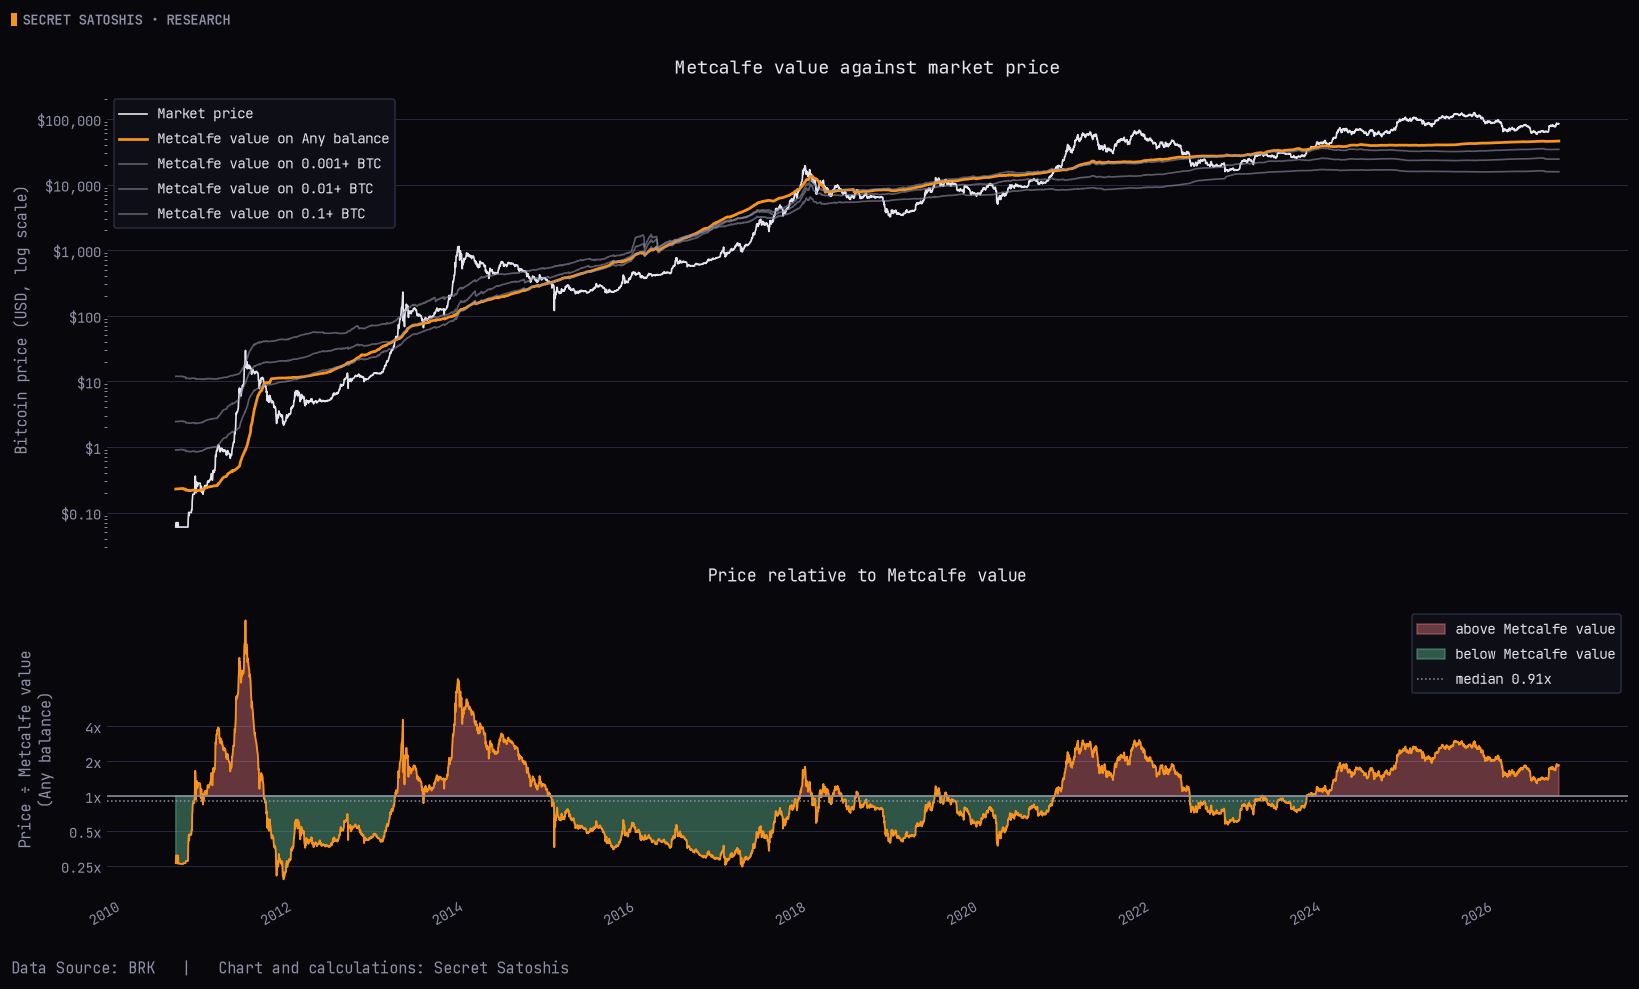

n is              Metcalfe value  price / value   median  percentile
Any balance               45,989          1.84x    0.91x         78%
0.001+ BTC                34,373          2.46x    0.90x         84%
0.01+ BTC                 24,382          3.47x    1.07x         88%
0.1+ BTC                  15,658          5.40x    1.24x         90%
market price              84,572

The four definitions give values within 2.94x of each other.

The same series, exponent refitted from later start years:
   2011 2.02   2013 2.06   2015 2.62   2017 3.08   2019 3.21   2021 2.30

The law fixes the shape at n squared; the constant is fitted here. So the level
is a rescaled address count, and only the ratio carries information.


In [12]:
# Metcalfe's law fixes the shape and nothing else: value is *proportional* to n
# squared, with no theoretical value for the constant. So the constant is fitted
# across the whole record and the output is read as a ratio, never as a level.
fits = {}
for col, label in BANDS.items():
    n = priced[col]
    ok = (priced["market_cap_usd"] > 0) & (n > 0)
    s = pd.DataFrame({"n": n[ok], "mcap": priced.loc[ok, "market_cap_usd"]})
    scale = np.exp((np.log(s["mcap"]) - 2 * np.log(s["n"])).mean())
    model = scale * n ** 2 / priced["supply"]
    fits[label] = (model, (priced["price"] / model).dropna())

HEADLINE = "Any balance"
model, ratio = fits[HEADLINE]

# Is the exponent a property of the network or of the window it was fitted on?
# The same test section 5 runs on time: refit from later start years and compare.
head_col = next(c for c, l in BANDS.items() if l == HEADLINE)
hn = priced[head_col]
hok = (priced["market_cap_usd"] > 0) & (hn > 0)
ln_n, ln_m = np.log(hn[hok]), np.log(priced.loc[hok, "market_cap_usd"])
exponents = {y: np.polyfit(ln_n[ln_n.index.year >= y], ln_m[ln_n.index.year >= y], 1)[0]
             for y in (2011, 2013, 2015, 2017, 2019, 2021)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                               gridspec_kw={"height_ratios": [1.6, 1]})

ax1.plot(priced.index, priced["price"], color=PRIMARY, linewidth=1.1, label="Market price")
for label, (m, _) in fits.items():
    lead = label == HEADLINE
    ax1.plot(m.index, m, color=ORANGE if lead else GREY, alpha=1.0 if lead else .6,
             linewidth=1.8 if lead else 1.1, label=f"Metcalfe value on {label}")
price_axis(ax1)
ax1.legend(fontsize=9, loc="upper left")
ax1.set_title("Metcalfe value against market price", fontsize=12, pad=12)

ax2.plot(ratio.index, ratio, color=ORANGE, linewidth=1.2)
ax2.fill_between(ratio.index, 1, ratio, where=ratio >= 1, color=RED, alpha=.4,
                 label="above Metcalfe value")
ax2.fill_between(ratio.index, 1, ratio, where=ratio < 1, color=GREEN, alpha=.4,
                 label="below Metcalfe value")
ax2.axhline(1, color=GREY, linewidth=1)
ax2.axhline(ratio.median(), color=GREY, linewidth=1, linestyle=":",
            label=f"median {ratio.median():.2f}x")
ax2.set_yscale("log"); ax2.set_ylabel(f"Price ÷ Metcalfe value\n({HEADLINE})")
ax2.set_yticks([0.25, 0.5, 1, 2, 4]); ax2.minorticks_off()
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}x"))
ax2.legend(fontsize=9, loc="upper right")
ax2.set_title("Price relative to Metcalfe value", fontsize=11)
finish(fig, sources=[BRK])

px_now = priced["price"].iloc[-1]
print(f"{'n is':<16}{'Metcalfe value':>16}{'price / value':>15}{'median':>9}{'percentile':>12}")
for label, (m, r) in fits.items():
    print(f"{label:<16}{m.iloc[-1]:>16,.0f}{px_now / m.iloc[-1]:>14.2f}x"
          f"{r.median():>8.2f}x{(r <= r.iloc[-1]).mean() * 100:>11.0f}%")
print(f"{'market price':<16}{px_now:>16,.0f}")

levels = [m.iloc[-1] for m, _ in fits.values()]
print(f"\nThe four definitions give values within {max(levels) / min(levels):.2f}x of each other.")
print("\nThe same series, exponent refitted from later start years:")
print("   " + "   ".join(f"{y} {b:.2f}" for y, b in exponents.items()))
print(f"\nThe law fixes the shape at n squared; the constant is fitted here. So the level")
print("is a rescaled address count, and only the ratio carries information.")

### What the chain could and could not tell us

This section asked how many people hold bitcoin. It could not answer, and how it failed is the finding.

**Address growth depends on the definition and period.** The preceding tables report the selected periods directly. Changes in custody, wallet behavior and dust thresholds can affect these counts without equivalent changes in ownership.

**Realized price is a ledger average, not a cost basis.** The dated output gives its value for this release. It is not the average price at which people bought.

**Owner estimates and addresses measure different objects.** Their common-year comparison shows the size of the gap without treating it as proof of custody's contribution. The notebook cannot identify the cause of the difference from these series alone.


---

# 3. US spot ETF trusts: a documented wrapper

Custody changes what an address means. Someone holding their own keys may spread coins across many addresses; an exchange or a fund may hold coins for a million people in very few. Both arrangements exist side by side — this is layers piling up, not each one replacing the last.

In January 2024 a new layer arrived. US spot bitcoin ETFs hold the coins while investors hold shares, so buying exposure no longer requires a crypto account at all. When shares change hands between investors, nothing happens on the chain and the fund's balance does not move. It moves only when shares are created or redeemed.

That is what makes this section different from the last one. The fund has to publish — what it holds, every day, and what came in or went out. It is not a window onto every shareholder: we cannot see who they are, how long they stay, or where the coins came from. But it is a counted number rather than a proxy, and it puts a pension fund and someone buying fifty dollars of an ETF in their brokerage account in the same place.

The flows also support an entry-price estimate: each day's net creations valued at that day's price, the dollars divided by the coins. That is a **flow-weighted entry price** for the coins the funds added since launch. It is built from daily flows, not a cost the funds report, and it is not any shareholder's cost basis. The funds do report a cost, once a quarter: the accounting cost of the bitcoin each one holds, shown below beside the estimate.

One wrinkle matters: total holdings and cumulative net acquisitions differ. Grayscale converted an existing trust to an ETF, bringing inherited inventory. The following dated output reports the current holdings and net-flow totals separately.

The first panel shows the coins held. The second sets the reference price against the market.

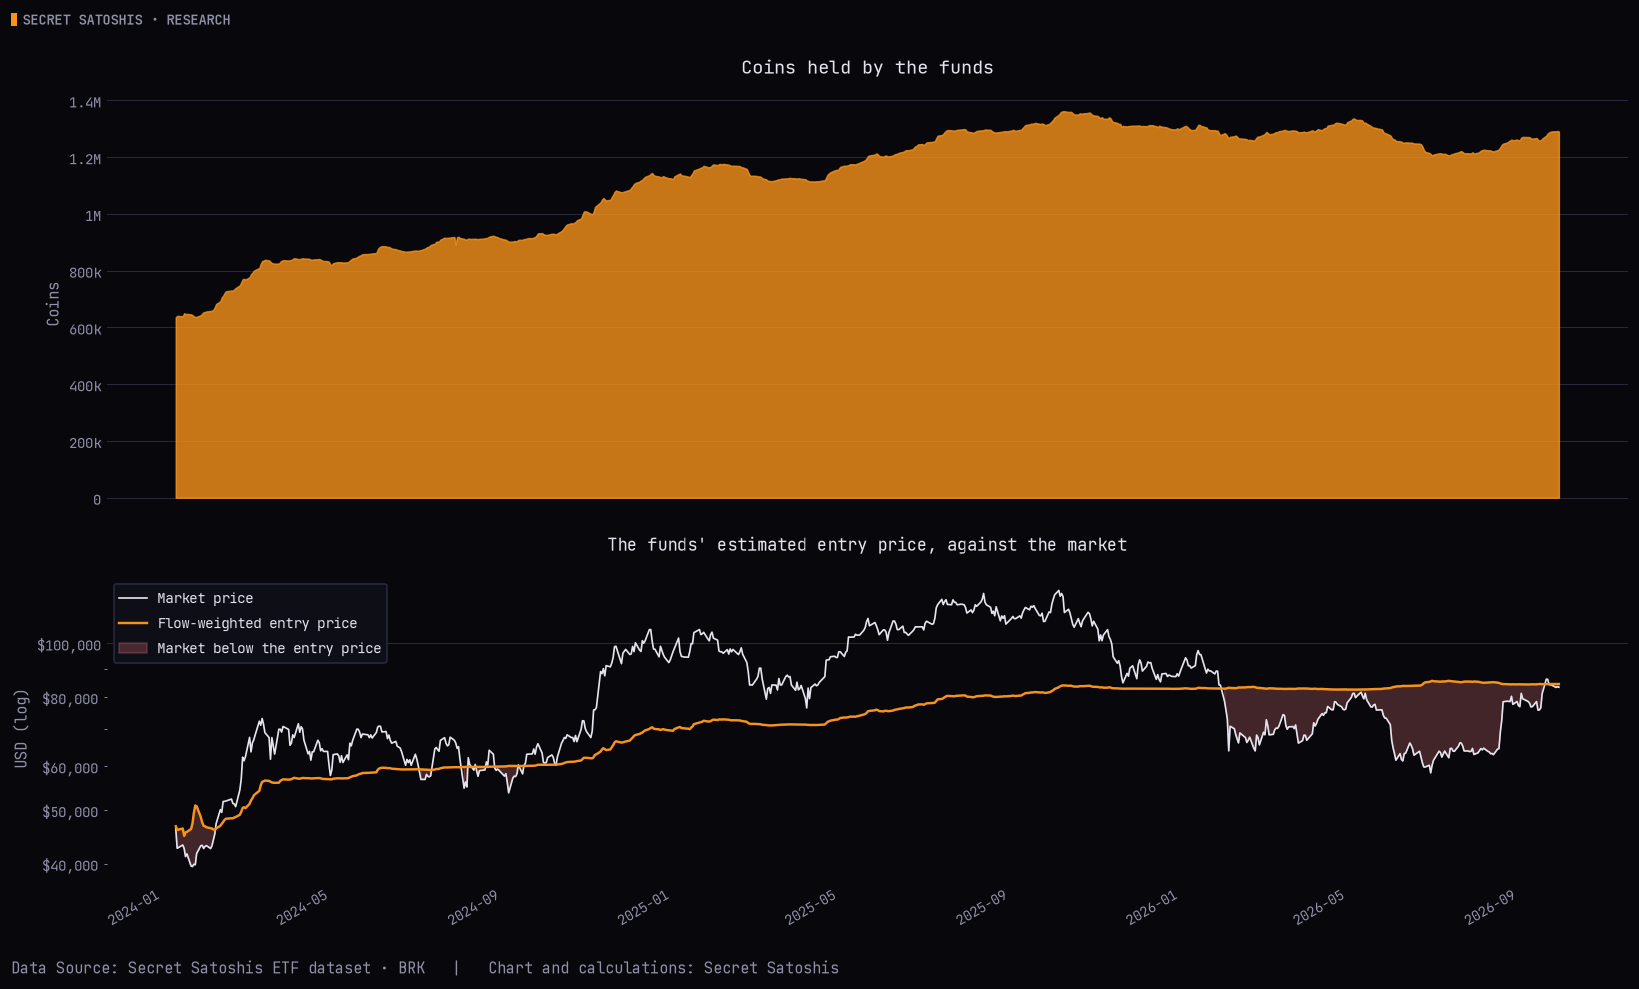

coins held by the funds                1,290,376
share of all bitcoin                       6.42%
coins bought, net, since launch          683,622
dollars committed, net            57,749,755,124
flow-weighted entry price                 84,476
market price                              83,347
market vs entry price                     -1.3%
reported cost per coin                    70,314   (11 funds' 2026-06-30 filings)
Largest single-day flow by any fund: 15,988 coins (GBTC).
ETF observations through 2026-09-30; market and supply comparison use that date.


In [13]:
etf_daily = pd.read_csv(INPUT_FILES["etf_daily"], parse_dates=["date"])
etf = pd.read_csv(INPUT_FILES["etf_totals"], parse_dates=["date"]).set_index("date").loc[:LAST_DAY]
etf_quarterly = pd.read_csv(INPUT_FILES["etf_quarterly"], parse_dates=["quarter_end"])
ETF_FIRST_DAY, ETF_LAST_DAY = etf.index.min(), etf.index.max()
fund_flows = etf_daily.pivot(index="date", columns="fund", values="flow_btc").loc[:LAST_DAY]

held = etf["total_btc"]
net_since_launch = etf["cumulative_flow_btc"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                               gridspec_kw={"height_ratios": [1.4, 1]})

ax1.fill_between(held.index, 0, held, color=ORANGE, alpha=.8)
ax1.set_ylabel("Coins")
ax1.yaxis.set_major_formatter(FuncFormatter(compact))
ax1.set_title("Coins held by the funds", fontsize=12, pad=12)

# Each day's net creations valued at that day's price, dollars divided by coins.
avg_paid = etf["flow_weighted_entry_price"]
mkt = priced["price"].reindex(avg_paid.index).ffill()
ax2.plot(mkt.index, mkt, color=PRIMARY, linewidth=1.1, label="Market price")
ax2.plot(avg_paid.index, avg_paid, color=ORANGE, linewidth=1.6,
         label="Flow-weighted entry price")
ax2.fill_between(avg_paid.index, mkt, avg_paid, where=mkt < avg_paid,
                 color=RED, alpha=.25, label="Market below the entry price")
price_axis(ax2, "USD (log)")
ax2.legend(fontsize=9, loc="upper left")
ax2.set_title("The funds' estimated entry price, against the market", fontsize=11)
finish(fig, sources=[ETF_DATASET, BRK])

print(f"{'coins held by the funds':<34}{held.iloc[-1]:>14,.0f}")
print(f"{'share of all bitcoin':<34}{held.iloc[-1] / daily.loc[ETF_LAST_DAY, 'supply'] * 100:>13.2f}%")
print(f"{'coins bought, net, since launch':<34}{net_since_launch.iloc[-1]:>14,.0f}")
print(f"{'dollars committed, net':<34}{etf['cumulative_flow_usd'].iloc[-1]:>14,.0f}")
print(f"{'flow-weighted entry price':<34}{avg_paid.iloc[-1]:>14,.0f}")
print(f"{'market price':<34}{mkt.iloc[-1]:>14,.0f}")
print(f"{'market vs entry price':<34}{mkt.iloc[-1] / avg_paid.iloc[-1] - 1:>13.1%}")

# The funds' own accounting cost, from their latest quarterly filings.
reported = etf_quarterly[etf_quarterly["fund"] == "ALL"].dropna(subset=["cost_per_btc"]).iloc[-1]
print(f"{'reported cost per coin':<34}{reported['cost_per_btc']:>14,.0f}"
      f"   ({int(reported['funds_with_cost'])} funds' {reported['quarter_end']:%Y-%m-%d} filings)")

print(f"Largest single-day flow by any fund: {fund_flows.abs().max().max():,.0f} coins "
      f"({fund_flows.abs().max().idxmax()}).")
print(f"ETF observations through {ETF_LAST_DAY:%Y-%m-%d}; market and supply comparison use that date.")


### How fast it is arriving

Holdings are a stock — how much is there. Creations and redemptions are a flow — how much arrived or left. The two come apart easily: shares can trade heavily all day between investors while the fund's balance never moves, because those trades never reach the trust.

So a flow is a change in how much exposure sits inside the wrapper. It is not a count of new buyers, and it is not proof that new money entered bitcoin — somebody rotating out of coins they held themselves and into a fund produces exactly the same reading.

The chart totals the same daily numbers by complete week and month, with price along the top so a run of buying or selling can be read against what the coin was doing at the time. Day-to-day flow tells you about timing; a month tells you whether it stuck. Part-finished periods at the edges are drawn faded and left out of the summary numbers, so a half-month is never set against a full one.

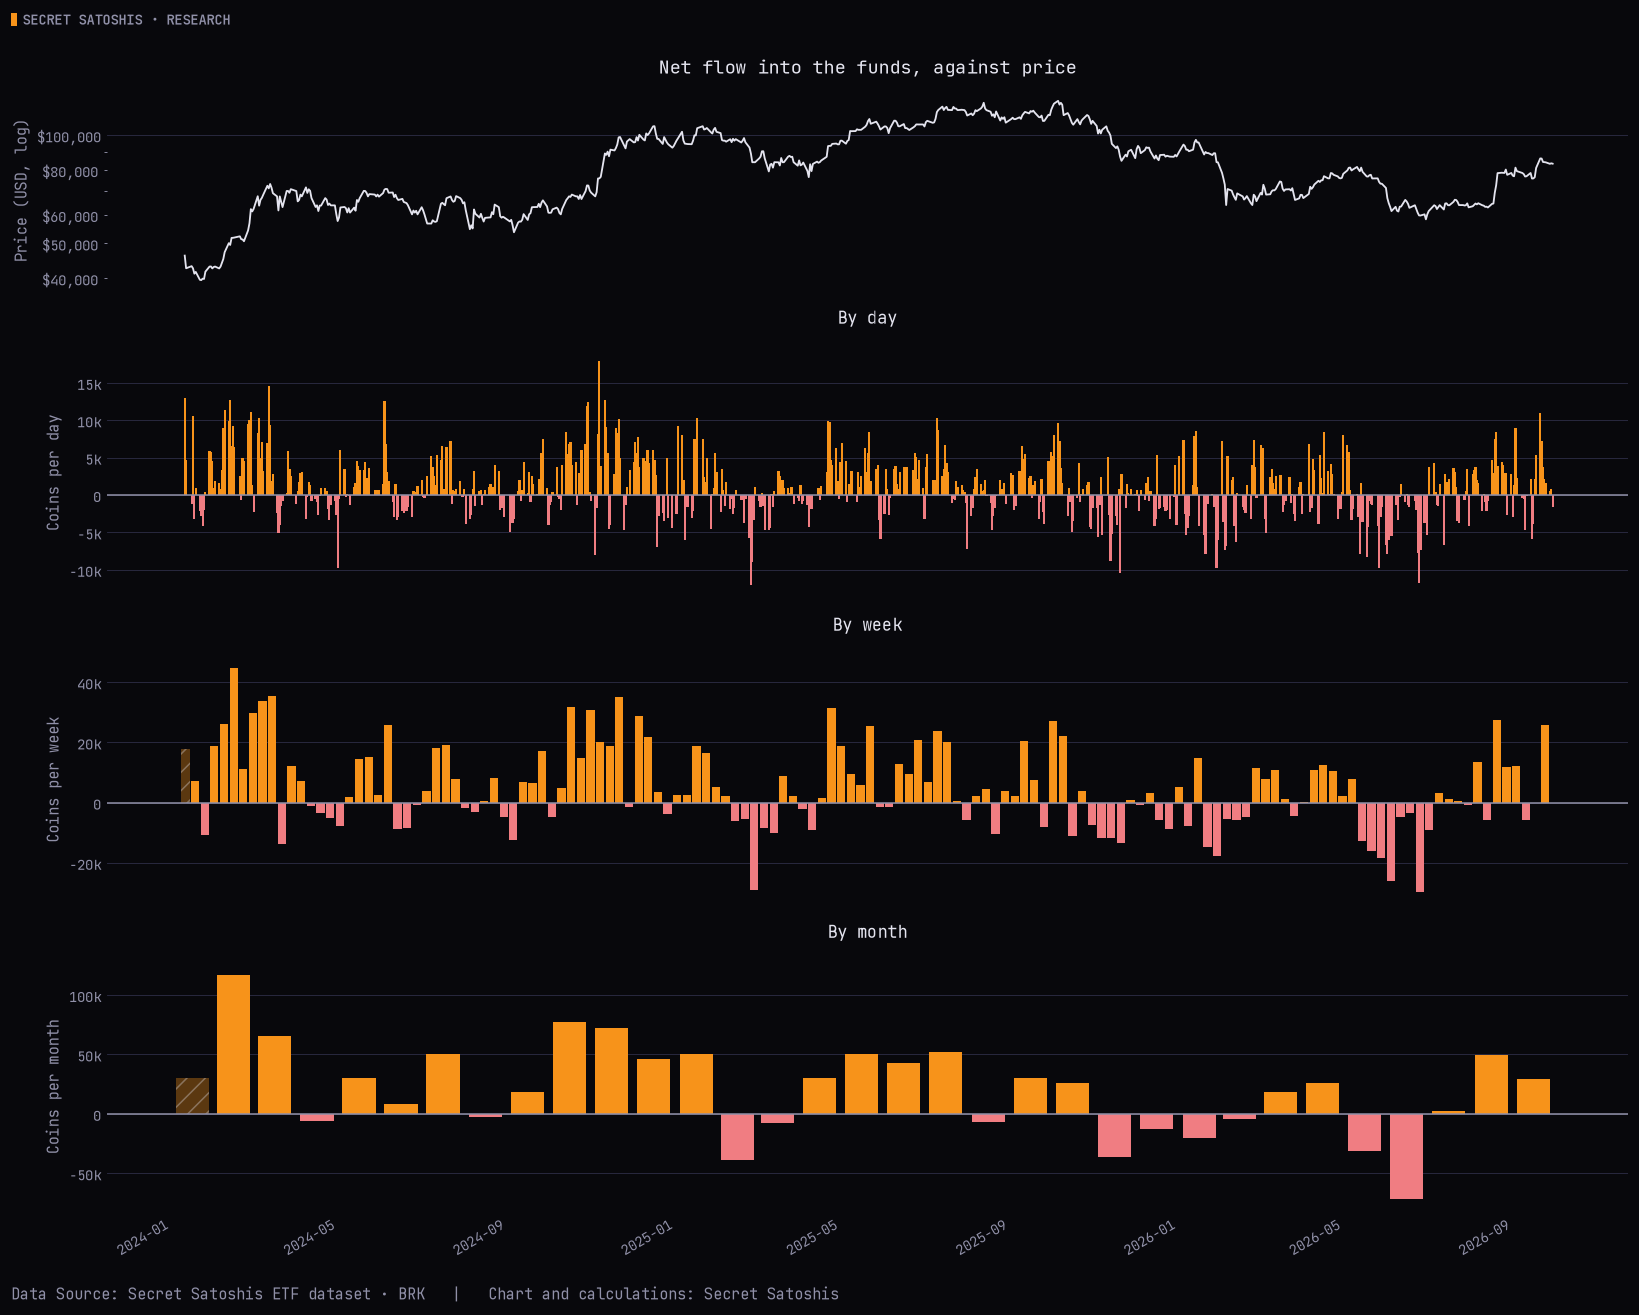

                largest    typical   ratio
daily            17,947      2,507      7x
weekly           44,749      8,355      5x
monthly         116,834     30,100      4x

Aggregation changes the scale of the observations; these ratios are descriptive,
not evidence that each timescale contains the same economic process.


In [14]:
STEPS = [("W", "W", 6, "By week"), ("ME", "M", 24, "By month")]
flow = etf["total_flow_btc"]
etf_price = priced["price"].reindex(flow.index).ffill()

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True,
                         gridspec_kw={"height_ratios": [.8, 1, 1, 1]})

# Price on top so a run of orange or red bars can be read against what the coin
# was doing at the time.
axes[0].plot(etf_price.index, etf_price, color=PRIMARY, linewidth=1.2)
price_axis(axes[0], "Price (USD, log)")
axes[0].set_title("Net flow into the funds, against price", fontsize=12, pad=12)

axes[1].bar(flow.index, flow.where(flow >= 0), width=1.6, color=ORANGE)
axes[1].bar(flow.index, flow.where(flow < 0), width=1.6, color=RED)
axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].set_ylabel("Coins per day")
axes[1].yaxis.set_major_formatter(FuncFormatter(compact))
axes[1].set_title("By day", fontsize=11)

for ax, (rule, code_, width, title) in zip(axes[2:], STEPS):
    agg = flow.resample(rule).sum(min_count=1)
    centers = period_centers(agg.index, code_)
    full = complete_periods(agg.index, code_, first=ETF_FIRST_DAY, last=ETF_LAST_DAY)
    for mask, alpha, hatch in ((full, 1.0, None), (~full, .35, "//")):
        pos, neg = agg.where(agg >= 0), agg.where(agg < 0)
        ax.bar(centers[mask], pos[mask], width=width, color=ORANGE, alpha=alpha, hatch=hatch)
        ax.bar(centers[mask], neg[mask], width=width, color=RED, alpha=alpha, hatch=hatch)
    ax.axhline(0, color=GREY, linewidth=1)
    ax.set_ylabel(f"Coins per {title.split()[-1]}")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.set_title(title, fontsize=11)
finish(fig, sources=[ETF_DATASET, BRK])

print(f"{'':<12}{'largest':>11}{'typical':>11}{'ratio':>8}")
for label, rule in (("daily", "D"), ("weekly", "W"), ("monthly", "ME")):
    s = flow if rule == "D" else flow.resample(rule).sum(min_count=1)
    if rule != "D":
        code = {"W": "W", "ME": "M"}[rule]
        s = s[complete_periods(s.index, code, first=ETF_FIRST_DAY, last=ETF_LAST_DAY)]
    s = s[s != 0].abs().dropna()
    print(f"{label:<12}{s.max():>11,.0f}{s.median():>11,.0f}{s.max() / s.median():>7.0f}x")
print("\nAggregation changes the scale of the observations; these ratios are descriptive,")
print("not evidence that each timescale contains the same economic process.")

### Measured against issuance

The subsidy creates coins that did not exist before. ETF creations move coins that did. Setting the two side by side compares their size in the same units; it is not an accounting where one has to absorb the other.

A positive flow does not mean those coins are gone from the market, and a negative one does not tell us who ended up selling. Coins can move from a long-time holder into a trust without total supply changing by a single satoshi.

The comparison answers one question and only one: how large were the changes in this wrapper next to the new coins being minted over the same stretch? It measures one channel, not demand.

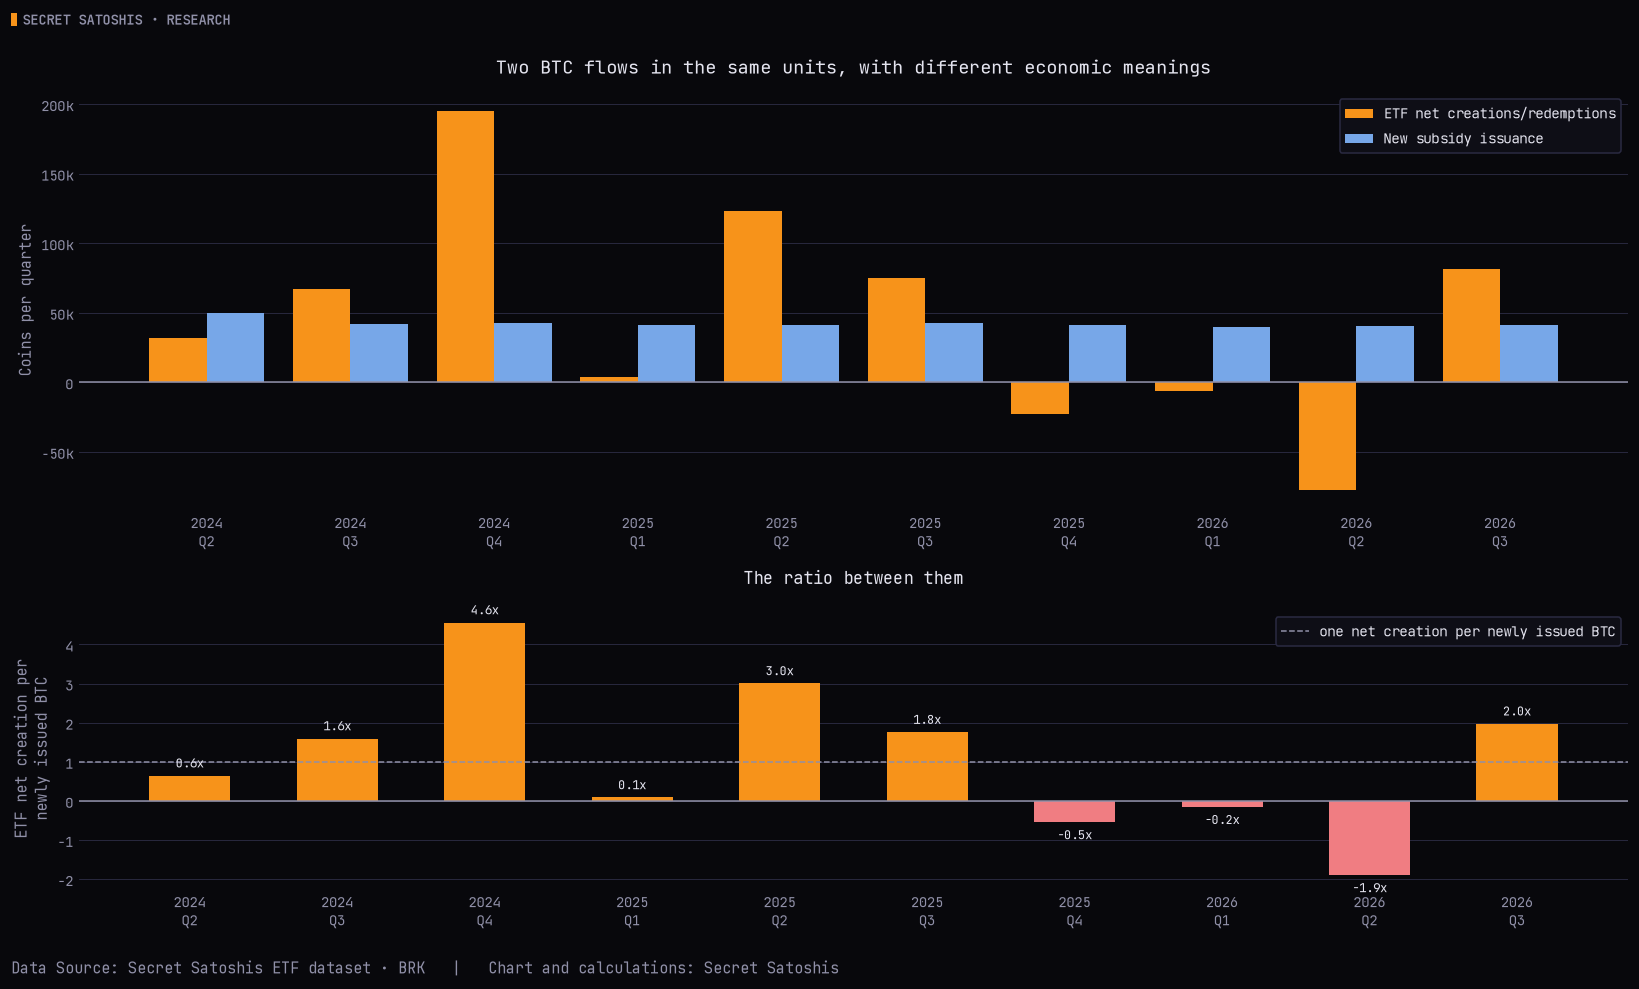

since ETF launch                   coins
  ETF net creations              683,622
  subsidy issuance               496,756
  scale ratio                      1.38x

Quarters with net ETF redemptions: 3 of 10 — 2025 Q4, 2026 Q1, 2026 Q2


In [15]:
window = slice(etf.index.min(), min(daily.index.max(), etf.index.max()))
issued = subsidy.loc[window]
net_creations = flow.loc[window]

q = pd.DataFrame({"ETF net creations": net_creations, "New issuance": issued}).resample("QE").sum(min_count=1)
q = q[complete_periods(q.index, "Q", first=ETF_FIRST_DAY, last=window.stop)]
x = np.arange(len(q))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={"height_ratios": [1.5, 1]})

ax1.bar(x - .2, q["ETF net creations"], width=.4, color=ORANGE, label="ETF net creations/redemptions")
ax1.bar(x + .2, q["New issuance"], width=.4, color=BLUE, label="New subsidy issuance")
ax1.axhline(0, color=GREY, linewidth=1)
ax1.set_xticks(x); ax1.set_xticklabels([f"{d.year}\nQ{d.quarter}" for d in q.index], fontsize=9)
ax1.set_ylabel("Coins per quarter")
ax1.yaxis.set_major_formatter(FuncFormatter(compact))
ax1.legend(fontsize=9)
ax1.set_title("Two BTC flows in the same units, with different economic meanings",
              fontsize=12, pad=12)

ratio = q["ETF net creations"] / q["New issuance"]
ax2.bar(x, ratio, width=.55, color=[ORANGE if v >= 0 else RED for v in ratio])
ax2.axhline(0, color=GREY, linewidth=1)
ax2.axhline(1, color=GREY, linestyle="--", linewidth=1, label="one net creation per newly issued BTC")
for xi, v in zip(x, ratio):
    ax2.annotate(f"{v:.1f}x", (xi, v), ha="center", fontsize=8,
                 va="bottom" if v >= 0 else "top", xytext=(0, 3 if v >= 0 else -3),
                 textcoords="offset points")
ax2.set_xticks(x); ax2.set_xticklabels([f"{d.year}\nQ{d.quarter}" for d in q.index], fontsize=9)
ax2.set_ylabel("ETF net creation per\nnewly issued BTC")
ax2.legend(fontsize=9, loc="upper right")
ax2.set_title("The ratio between them", fontsize=11)
finish(fig, sources=[ETF_DATASET, BRK])

print(f"{'since ETF launch':<26}{'coins':>14}")
print(f"{'  ETF net creations':<26}{net_creations.sum():>14,.0f}")
print(f"{'  subsidy issuance':<26}{issued.sum():>14,.0f}")
print(f"{'  scale ratio':<26}{net_creations.sum() / issued.sum():>13.2f}x")
neg = ratio[ratio < 0]
print(f"\nQuarters with net ETF redemptions: {len(neg)} of {len(ratio)}"
      f"{' — ' + ', '.join(f'{d.year} Q{d.quarter}' for d in neg.index) if len(neg) else ''}")

### What the funds show

The output gives the coins actually held, the total created since launch, the flows by complete period, and their size against issuance. Signs flip: a redemption is money leaving the wrapper, which is not the same as an investor turning bearish.

Three things this section could do that the last one could not.

**It separates what is held from what moved.** Reported holdings and net purchases are two different numbers; their values and coverage date are shown in the preceding output.

**It gives an entry price two ways.** The flow-weighted entry price values each day's creations at that day's price; it approximates what the funds paid for coins added since launch. The reported cost per coin is the funds' own accounting figure from their filings, once a quarter. Neither is a shareholder's cost basis.

**It counts retail and institutions together** — without telling us how the total splits between them.

What it does not cover is everything else: coins on exchanges, coins in self-custody, funds listed outside the US, derivatives, and everyone who wanted to buy and did not.

The next section changes the evidence again — from a series published daily to snapshots that arrive whenever an entity gets around to filing.

---

# 4. Selected reserve positions: dated and uneven evidence

Company and government balances are photographs taken at odd intervals. A balance says what was held on a date. It says nothing about demand now, unless a purchase or a sale is documented separately.

The sources are mixed. Company positions come from CoinGecko's public treasuries list, which compiles filings and announcements rather than auditing them. Government figures come from official statements, or from analysts tracing coins on the chain and attributing them to a state. Coverage differs, reporting dates differ, and what counts as one entity differs once subsidiaries are involved.

So this section reports positions and where they came from. It is not a census, and it is not a rate of buying.

| Tier | Source | What it supports |
|---|---|---|
| **Filed** | A dated regulatory or financial disclosure | A strong claim about that entity on that date |
| **Announced** | An official statement or press release | The claim as made, with nobody auditing it |
| **Estimated** | An aggregator's compilation, or chain forensics | Rough size, only as good as the method and how stale it is |

Where the same issuer appears more than once under different spellings, the notebook keeps a single position per ticker so nothing is counted twice. Every row still carries whatever date the aggregator last recorded, so the total is a stack of positions read on different days rather than a snapshot taken at one moment.

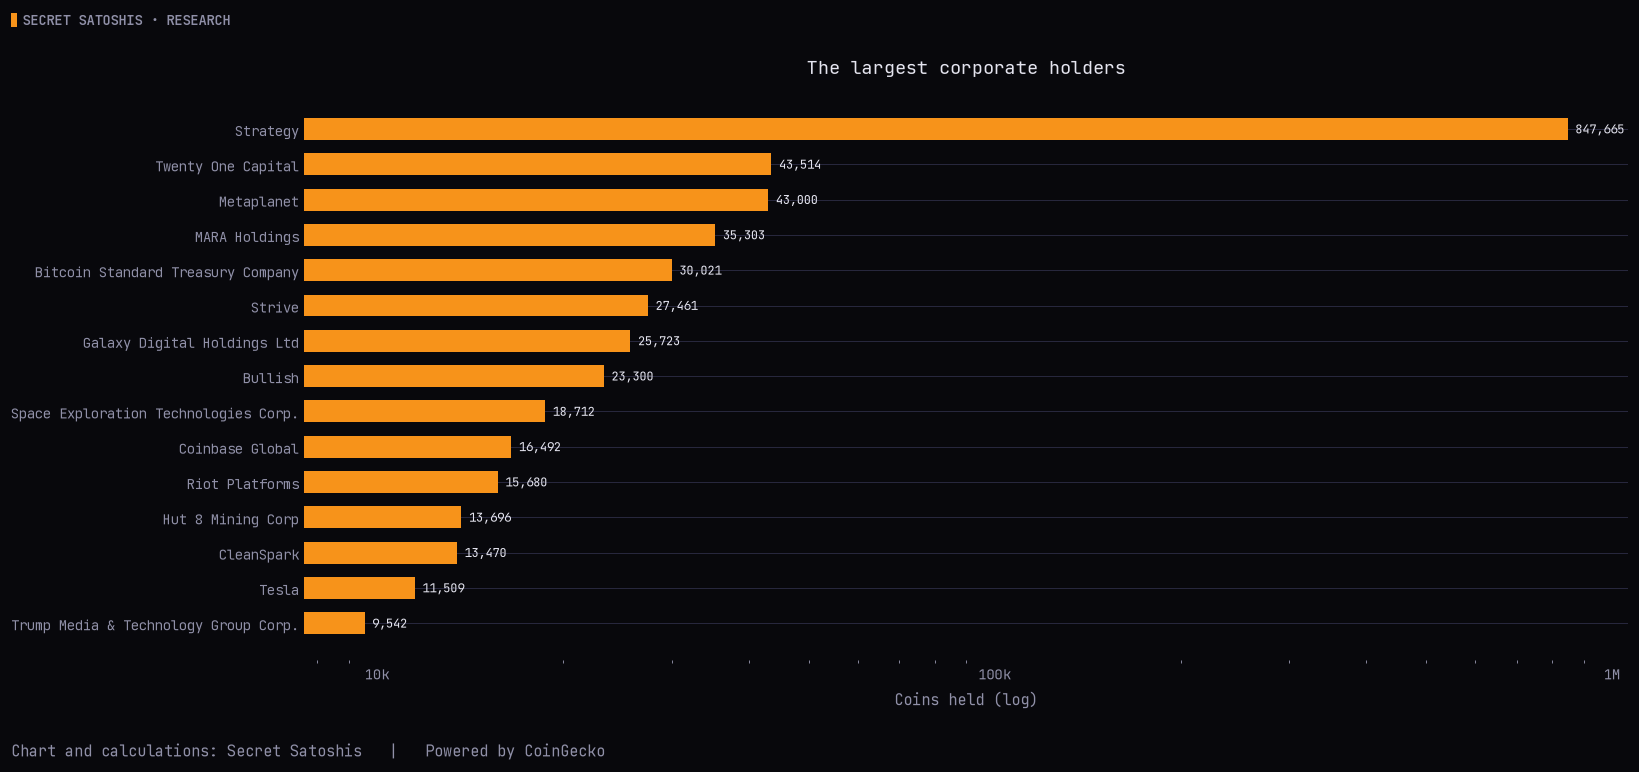

companies reporting a position             180
after merging duplicate listings           180
coins held                           1,298,213
share of all bitcoin                     6.46%

The largest single position is 65% of the corporate total, and the top five are 77%.
These are dated disclosures compiled by one aggregator, not a synchronized snapshot.


In [16]:
listed = companies.dropna(subset=["btc"])
top = listed.nlargest(15, "btc").iloc[::-1]
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(15, 7))
ax.barh(y, top["btc"], height=.62, color=ORANGE)
ax.set_yticks(y); ax.set_yticklabels(top["entity"], fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("Coins held (log)")
ax.xaxis.set_major_formatter(FuncFormatter(compact))
for yi, v in zip(y, top["btc"]):
    ax.annotate(f"{v:,.0f}", (v, yi), va="center", ha="left", fontsize=8,
                xytext=(5, 0), textcoords="offset points")
finish(fig, "The largest corporate holders", ax, sources=[COINGECKO])

# One position per issuer: group by ticker where there is one, otherwise by a
# normalized name, so the same company under two spellings is not counted twice.
entity_key = listed["ticker"].fillna(
    listed["entity"].str.lower().str.replace(r"[^a-z0-9]+", "", regex=True)
)
company_positions = (listed.assign(entity_key=entity_key)
                     .groupby("entity_key", as_index=False)["btc"].max())

total = company_positions["btc"].sum()
ranked = company_positions["btc"].sort_values(ascending=False)
print(f"{'companies reporting a position':<34}{len(listed):>12,.0f}")
print(f"{'after merging duplicate listings':<34}{len(company_positions):>12,.0f}")
print(f"{'coins held':<34}{total:>12,.0f}")
print(f"{'share of all bitcoin':<34}{total / daily['supply'].iloc[-1] * 100:>11.2f}%")
print(f"\nThe largest single position is {ranked.iloc[0] / total * 100:.0f}% of the corporate total, "
      f"and the top five are {ranked.head(5).sum() / total * 100:.0f}%.")
print("These are dated disclosures compiled by one aggregator, not a synchronized snapshot.")

### Three ways a state ends up holding bitcoin

A government balance can come about in ways that have nothing to do with each other, so the source's classification is kept rather than lumping it all together as demand.

**Bought.** A documented purchase on the market. This one is demand, at a time and a price.

**Mined.** The state spent on power and hardware and received block rewards. Real expenditure, but not a purchase from a seller.

**Seized or stolen.** Coins taken through forfeiture or expropriation. Legal control changed hands; nobody bought anything. These are holdings, and counting them as state demand would be wrong.

Where the source cannot say how the coins were acquired, they stay unclassified. The labels are only as good as the table they come from.

Only national holdings are totalled. US states, cities and officials' personal declarations are listed separately: they are not national reserves, and a sub-national reserve held through ETF shares (Texas) is already inside the ETF total.

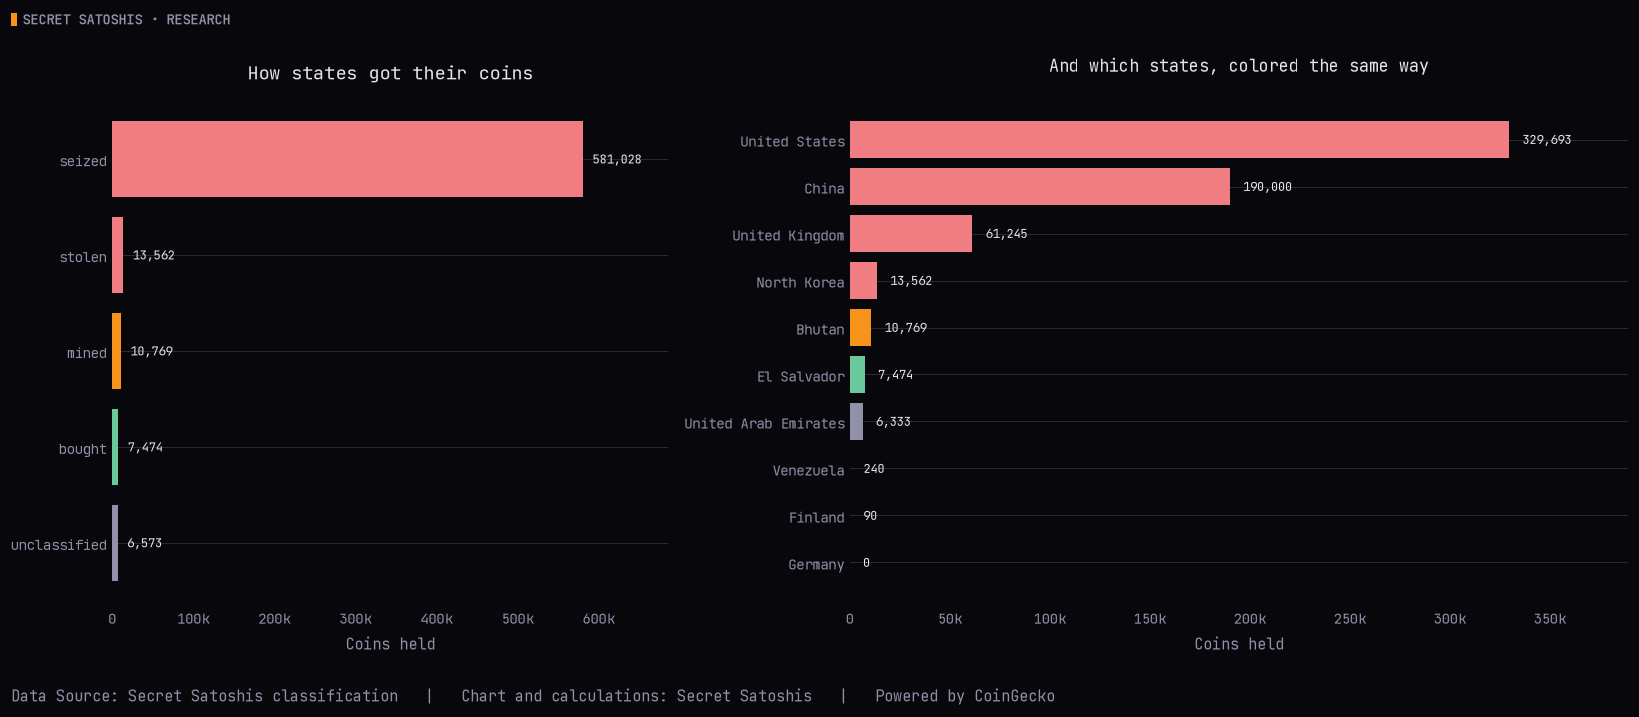

acquisition            coins    share
seized               581,028    93.8%
stolen                13,562     2.2%
mined                 10,769     1.7%
bought                 7,474     1.2%
unclassified           6,573     1.1%
total                619,406

Coins classified as bought or mined: 18,243 — 2.9% of the estimated national total.

Listed but not totalled:
  Texas                              57.47 coins  (sub-national, bought)
  Roswell, New Mexico                 0.04 coins  (sub-national, donated)


In [17]:
def label_bars(ax, values, pad=.02):
    """Write each value at the end of its bar and leave room for the text."""
    top = max(values)
    for i, v in enumerate(values):
        ax.annotate(f"{v:,.0f}", (v + top * pad, i), va="center", ha="left", fontsize=8)
    ax.set_xlim(0, top * 1.18)


gov = governments[governments["jurisdiction"] == "national"].copy()
excluded = governments[governments["jurisdiction"] != "national"]

by_type = gov.groupby("acquisition_type")["btc"].sum().sort_values()
COLORS = {"bought": GREEN, "mined": ORANGE, "donated": ORANGE, "seized": RED, "stolen": RED,
          "unclassified": GREY}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1, 1.4]})

ax1.barh(by_type.index, by_type.values, color=[COLORS[i] for i in by_type.index])
ax1.set_xlabel("Coins held"); ax1.xaxis.set_major_formatter(FuncFormatter(compact))
ax1.set_title("How states got their coins", fontsize=12, pad=12)

# The holdings span three orders of magnitude, so on a linear axis the smaller
# categories have no visible bar. Every value is labelled instead.
label_bars(ax1, by_type.values)

states = gov.nlargest(10, "btc").iloc[::-1]
ax2.barh(states["entity"], states["btc"],
         color=[COLORS[t] for t in states["acquisition_type"]])
ax2.set_xlabel("Coins held"); ax2.xaxis.set_major_formatter(FuncFormatter(compact))
ax2.tick_params(axis="y", labelsize=9)
ax2.set_title("And which states, colored the same way", fontsize=11)
label_bars(ax2, states["btc"].values)
finish(fig, sources=[COINGECKO, CLASSIFICATION])

total = gov["btc"].sum()
print(f"{'acquisition':<16}{'coins':>12}{'share':>9}")
for t, v in by_type.sort_values(ascending=False).items():
    print(f"{t:<16}{v:>12,.0f}{v / total * 100:>8.1f}%")
print(f"{'total':<16}{total:>12,.0f}")

bid = by_type.get("bought", 0) + by_type.get("mined", 0)
print(f"\nCoins classified as bought or mined: {bid:,.0f} — {bid / total * 100:.1f}% of the estimated national total.")
if not excluded.empty:
    print("\nListed but not totalled:")
    for _, row in excluded.iterrows():
        print(f"  {row['entity']:<28}{row['btc']:>12,.2f} coins  ({row['jurisdiction'].replace('_', '-')}, "
              f"{row['acquisition_type']})")

### What the selected categories add up to

The last bar sets the ETF trusts, the company total, and the government estimate against total supply. It is a rough comparison of size, not an audit.

The grey band is labeled **outside selected categories** rather than undisclosed, and the distinction is the point. It holds coins we know exist and did not tabulate — exchange balances, funds listed elsewhere, everyone holding their own keys — alongside coins nobody can account for at all. It is what is left over, not a measurement.

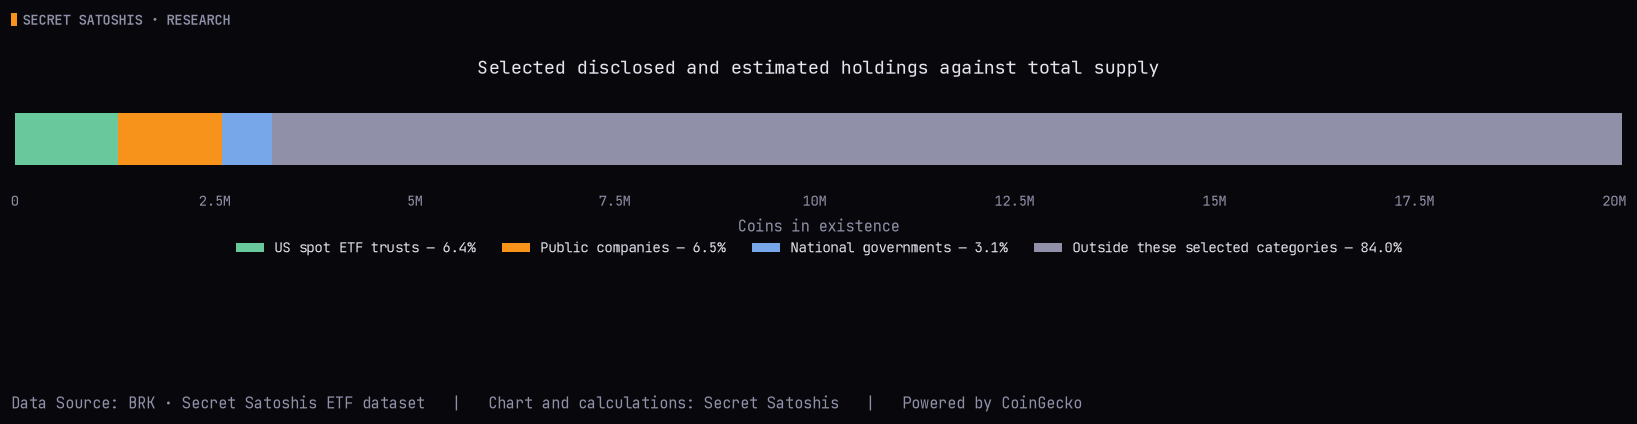

category                                     coins    share
US spot ETF trusts                       1,290,376     6.4%
Public companies                         1,298,213     6.5%
National governments                       619,406     3.1%
Outside selected categories             16,883,981    84.0%

Selected categories total: 3,207,995 coins, 16.0% of supply.
Source dates and evidence standards differ. This arithmetic assumes no cross-category overlap beyond the issuer-name check above.


In [18]:
supply_now = daily["supply"].iloc[-1]
funds = held.iloc[-1]
corporate = company_positions["btc"].sum()
sovereign = gov["btc"].sum()

# The three groups have to be disjoint or the total is nonsense. No ETF issuer
# should appear in the corporate treasury table.
FUND_NAMES = "grayscale|blackrock|ishares|fidelity|21shares|bitwise|vaneck|invesco|franklin|valkyrie|etf"
overlap = companies["entity"].str.lower().str.contains(FUND_NAMES, na=False)
if overlap.any():
    raise ValueError(f"fund issuers found among companies: {list(companies.loc[overlap, 'entity'])}")

outside_selected = supply_now - funds - corporate - sovereign
if outside_selected < 0:
    raise ValueError("selected holding categories exceed observed supply; inspect overlap and source dates")

fig, ax = plt.subplots(figsize=(15, 3.8))
left = 0
for label, value, color in (("US spot ETF trusts", funds, GREEN),
                            ("Public companies", corporate, ORANGE),
                            ("National governments", sovereign, BLUE),
                            ("Outside these selected categories", outside_selected, GREY)):
    ax.barh([0], [value], left=left, color=color, height=.55,
            label=f"{label} — {value / supply_now * 100:.1f}%")
    left += value
ax.set_xlim(0, supply_now); ax.set_ylim(-.5, .5); ax.set_yticks([])
ax.xaxis.set_major_formatter(FuncFormatter(compact))
ax.set_xlabel("Coins in existence")
ax.grid(False)
ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(.5, -.42), ncol=4, frameon=False)
finish(fig, "Selected disclosed and estimated holdings against total supply", ax, sources=[BRK, ETF_DATASET, COINGECKO])

print(f"{'category':<38}{'coins':>12}{'share':>9}")
for label, value in (("US spot ETF trusts", funds), ("Public companies", corporate),
                     ("National governments", sovereign),
                     ("Outside selected categories", outside_selected)):
    print(f"{label:<38}{value:>12,.0f}{value / supply_now * 100:>8.1f}%")
documented = funds + corporate + sovereign
print(f"\nSelected categories total: {documented:,.0f} coins, {documented / supply_now * 100:.1f}% of supply.")
print("Source dates and evidence standards differ. This arithmetic assumes no cross-category overlap beyond the issuer-name check above.")

---

# 5. Price against time

This section compares two fitted shapes: exponential growth (a constant proportional rate) and a power law in days since genesis. Both are descriptions of the observed price record. Their fit errors do not establish a cause or a future growth rule.

For a positive power-law exponent, the fitted proportional growth rate declines with age. Its doubling time therefore increases with age. The following output calculates the fitted exponent, doubling times and errors from this release rather than assuming fixed values.

Logarithmic growth is another distinct shape: it grows without bound, with diminishing absolute increments. It does not approach a finite ceiling. No logarithmic model is fitted or rejected here.

The first chart uses log-log axes; the second uses calendar time and a logarithmic price axis. Dotted lines extend a fitted shape ten years beyond the data as a conditional illustration. The extrapolation is not a validated forecast.


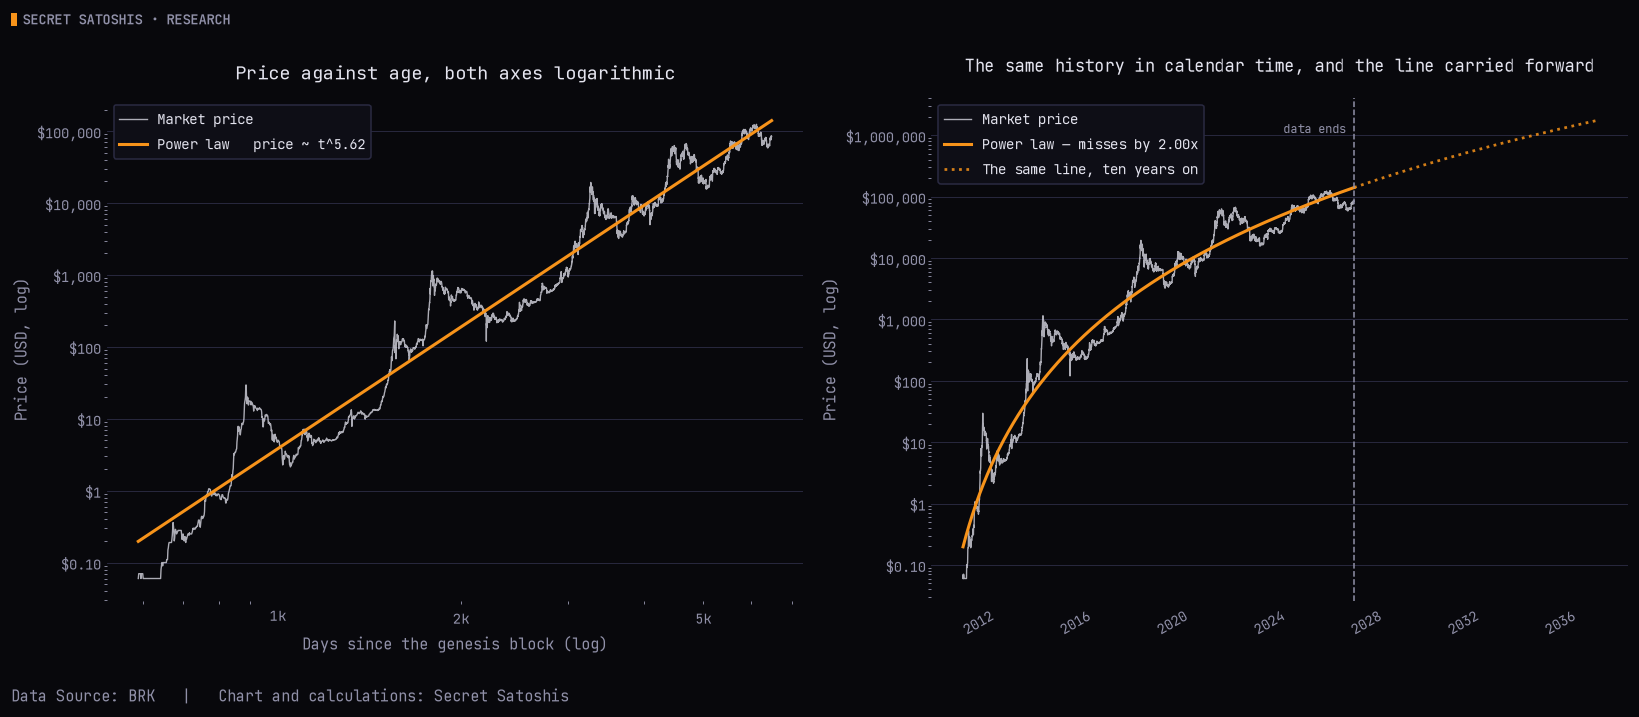

power law   price ∝ t^k         
  exponent k                            5.62
  model today                        140,508
  price ÷ model                        0.60x
  typical miss                         2.00x
steady compounding              
  implied rate                          100%  a year
  model today                        533,649
  typical miss                         3.56x

A power law decelerates. Time for the fitted model to double, by year:
  from 2013     0.5 years
  from 2016     0.9 years
  from 2019     1.3 years
  from 2022     1.7 years
  from 2025     2.1 years

Steady compounding fitted on the first five years runs at 721% a year. Carried forward, it puts a coin at $1e+14
today. The market says $84,572. Growth that slows down is the whole content
of the power-law claim, and it is why steady compounding is the wrong shape.

Carried ten years past the data, the fitted line reaches $1,733,553 in 2036.
That is the shape continued, not a forecast. Nothing here says t

In [19]:
pl = priced.dropna(subset=["price", "days_since_genesis"])
pl = pl[pl["price"] > 0]
age, px = pl["days_since_genesis"], pl["price"]

# A power law is a fixed exponent on time: price = A * t**k. Taking logs of both
# sides makes it a straight line of slope k, which is the only reason the left
# panel uses log-log axes.
k, a = np.polyfit(np.log(age), np.log(px), 1)
model_pl = np.exp(a) * age ** k

# The alternative worth ruling out is steady compounding: a constant percentage
# per year, which is straight against calendar time on a log price axis.
g, b = np.polyfit(age, np.log(px), 1)
model_exp = np.exp(b) * np.exp(g * age)
annual = (np.exp(g * 365.25) - 1) * 100


def typical_miss(model):
    """Geometric average of how far the model sits from price, as a multiple."""
    return np.exp(np.sqrt(np.mean(np.log(px / model) ** 2)))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

ax1.plot(age, px, color=PRIMARY, linewidth=.9, alpha=.75, label="Market price")
ax1.plot(age, model_pl, color=ORANGE, linewidth=2, label=f"Power law   price ~ t^{k:.2f}")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("Days since the genesis block (log)")
ax1.set_ylabel("Price (USD, log)")
log_axis(ax1.xaxis, compact)
log_axis(ax1.yaxis, usd)
ax1.legend(fontsize=9, loc="upper left")
ax1.set_title("Price against age, both axes logarithmic", fontsize=12, pad=12)

# Carry the fitted line ten years past the data. This is the shape continued,
# not a forecast: the same fit sits a factor of two from price on a typical day.
AHEAD = 365 * 10
future = pd.date_range(pl.index[-1] + pd.Timedelta(days=1), periods=AHEAD, freq="D")
future_age = age.iloc[-1] + np.arange(1, AHEAD + 1)
future_model = np.exp(a) * future_age ** k

ax2.plot(pl.index, px, color=PRIMARY, linewidth=.9, alpha=.75, label="Market price")
ax2.plot(pl.index, model_pl, color=ORANGE, linewidth=2,
         label=f"Power law — misses by {typical_miss(model_pl):.2f}x")
ax2.plot(future, future_model, color=ORANGE, linewidth=1.8, linestyle=":", alpha=.85,
         label="The same line, ten years on")
ax2.axvline(pl.index[-1], color=GREY, linewidth=1, linestyle="--")
ax2.annotate("data ends", (pl.index[-1], future_model[-1]), fontsize=8, color=GREY,
             ha="right", va="top", xytext=(-5, 0), textcoords="offset points")
price_axis(ax2, "Price (USD, log)")
ax2.legend(fontsize=9, loc="upper left")
ax2.set_title("The same history in calendar time, and the line carried forward", fontsize=11)
finish(fig, sources=[BRK])

print(f"{'power law   price ∝ t^k':<32}")
print(f"{'  exponent k':<32}{k:>12.2f}")
print(f"{'  model today':<32}{model_pl.iloc[-1]:>12,.0f}")
print(f"{'  price ÷ model':<32}{px.iloc[-1] / model_pl.iloc[-1]:>11.2f}x")
print(f"{'  typical miss':<32}{typical_miss(model_pl):>11.2f}x")
print(f"{'steady compounding':<32}")
print(f"{'  implied rate':<32}{annual:>11.0f}%  a year")
print(f"{'  model today':<32}{model_exp.iloc[-1]:>12,.0f}")
print(f"{'  typical miss':<32}{typical_miss(model_exp):>11.2f}x")

print("\nA power law decelerates. Time for the fitted model to double, by year:")
for year in (2013, 2016, 2019, 2022, 2025):
    t0 = pl[pl.index.year == year]["days_since_genesis"].iloc[0]
    print(f"  from {year}{t0 * (2 ** (1 / k) - 1) / 365.25:>8.1f} years")

early = pl[pl["days_since_genesis"] <= 5 * 365.25]
ge, be = np.polyfit(early["days_since_genesis"], np.log(early["price"]), 1)
print(f"\nSteady compounding fitted on the first five years runs at "
      f"{(np.exp(ge * 365.25) - 1) * 100:,.0f}% a year. Carried forward, it puts a coin at "
      f"${np.exp(be + ge * age.iloc[-1]):.0e}")
print(f"today. The market says ${px.iloc[-1]:,.0f}. Growth that slows down is the whole content")
print("of the power-law claim, and it is why steady compounding is the wrong shape.")

print(f"\nCarried ten years past the data, the fitted line reaches "
      f"${future_model[-1]:,.0f} in {future[-1].year}.")
print("That is the shape continued, not a forecast. Nothing here says the shape continues.")

### How sensitive is the fit?

Time is an explanatory variable in this regression, not an identified economic cause. Adoption, mining and market structure may influence prices, but the fit does not isolate any of those mechanisms.

The next chart refits from five start years. These windows are nested and overlap heavily: all include the most recent segment. This is a sensitivity check on the chosen start date, not five independent confirmations or an out-of-sample test. The output reports their exponent range, current levels and extrapolated spread.

Deviation statistics describe the same fitted history. Counts of crossings, time below the line and historical percentiles are calculated below for the loaded release. Being below a fitted line does not establish a discount, a trading signal or reliable mean reversion. A sustained deviation can also indicate that the model no longer describes the data.


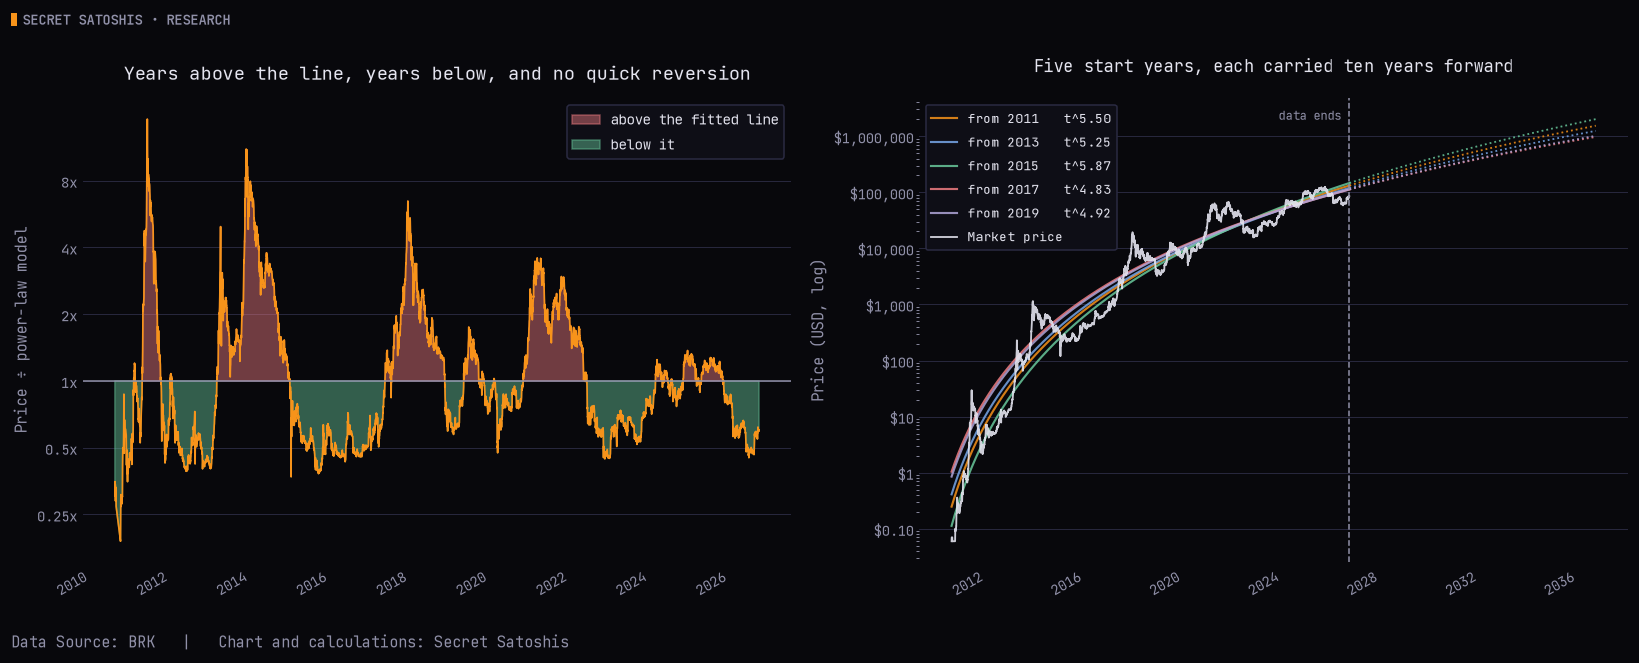

reading at cutoff               0.60x
percentile of its history        28%
median                          0.86x
share of days below the line     56%
crossings of the line             68  in 16 years
longest stretch below            870 days

fit from      exponent         today  price ÷ model    in ten years
2011              5.50       131,716          0.64x       1,537,564
2013              5.25       119,350          0.71x       1,244,950
2015              5.87       146,124          0.58x       2,014,333
2017              4.83       111,980          0.76x         970,708
2019              4.92       112,740          0.75x       1,015,857
market                        84,572

Exponents run 4.83 to 5.87 across start years, and today those fits sit within 1.30x
of each other. Ten years out they span 2.08x — 970,708 to 2,014,333.
Small differences in the exponent are quiet in the present and loud in the future.


In [20]:
deviation = (px / model_pl).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(deviation.index, deviation, color=ORANGE, linewidth=1.1)
ax1.fill_between(deviation.index, 1, deviation, where=deviation >= 1, color=RED, alpha=.45,
                 label="above the fitted line")
ax1.fill_between(deviation.index, 1, deviation, where=deviation < 1, color=GREEN, alpha=.45,
                 label="below it")
ax1.axhline(1, color=GREY, linewidth=1)
ax1.set_yscale("log"); ax1.set_ylabel("Price ÷ power-law model")
ax1.set_yticks([0.25, 0.5, 1, 2, 4, 8]); ax1.minorticks_off()
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}x"))
ax1.legend(fontsize=9, loc="upper right")
ax1.set_title("Years above the line, years below, and no quick reversion",
              fontsize=12, pad=12)

# Refit from later start years. If the exponent were an artifact of the early
# near-zero prices, moving the start would move it a long way.
STARTS = [2011, 2013, 2015, 2017, 2019]
rows = []
for year in STARTS:
    seg = pl[pl.index.year >= year]
    kk, aa = np.polyfit(np.log(seg["days_since_genesis"]), np.log(seg["price"]), 1)
    line = np.exp(aa) * age ** kk
    ahead = np.exp(aa) * future_age ** kk
    rows.append((year, kk, line.iloc[-1], ahead[-1]))
    drawn, = ax2.plot(pl.index, line, linewidth=1.4, alpha=.85, label=f"from {year}   t^{kk:.2f}")
    # Each fit continued on the same terms, so the fan shows where the choice of
    # start year actually costs something.
    ax2.plot(future, ahead, color=drawn.get_color(), linewidth=1.2, linestyle=":", alpha=.85)
ax2.plot(pl.index, px, color=PRIMARY, linewidth=1.2, alpha=.9, label="Market price")
ax2.axvline(pl.index[-1], color=GREY, linewidth=1, linestyle="--")
ax2.annotate("data ends", xy=(pl.index[-1], .98), xycoords=("data", "axes fraction"),
             fontsize=8, color=GREY, ha="right", va="top", xytext=(-5, 0),
             textcoords="offset points")
price_axis(ax2, "Price (USD, log)")
ax2.legend(fontsize=8.5, loc="upper left")
ax2.set_title("Five start years, each carried ten years forward", fontsize=11)
finish(fig, sources=[BRK])

pct = (deviation < deviation.iloc[-1]).mean() * 100
above_line = deviation >= 1
# The first observation establishes the initial state; it is not a crossing.
crossings = above_line.ne(above_line.shift()).iloc[1:].sum()
print(f"{'reading at cutoff':<28}{deviation.iloc[-1]:>8.2f}x")
print(f"{'percentile of its history':<28}{pct:>7.0f}%")
print(f"{'median':<28}{deviation.median():>8.2f}x")
print(f"{'share of days below the line':<28}{(deviation < 1).mean() * 100:>7.0f}%")
print(f"{'crossings of the line':<28}{int(crossings):>8}  in {len(deviation) / 365.25:.0f} years")
print(f"{'longest stretch below':<28}"
      f"{(~(deviation >= 1)).groupby((deviation >= 1).cumsum()).sum().max():>8.0f} days")

print(f"\n{'fit from':<12}{'exponent':>10}{'today':>14}{'price ÷ model':>15}{'in ten years':>16}")
for year, kk, m, ahead in rows:
    print(f"{year:<12}{kk:>10.2f}{m:>14,.0f}{px.iloc[-1] / m:>14.2f}x{ahead:>16,.0f}")
print(f"{'market':<12}{'':>10}{px.iloc[-1]:>14,.0f}")

now_span = max(r[2] for r in rows) / min(r[2] for r in rows)
ten_span = max(r[3] for r in rows) / min(r[3] for r in rows)
print(f"\nExponents run {min(r[1] for r in rows):.2f} to {max(r[1] for r in rows):.2f} across start years, and "
      f"today those fits sit within {now_span:.2f}x")
print(f"of each other. Ten years out they span {ten_span:.2f}x — {min(r[3] for r in rows):,.0f} to "
      f"{max(r[3] for r in rows):,.0f}.")
print("Small differences in the exponent are quiet in the present and loud in the future.")

### Five lenses, one question

The notebook has now produced five numbers that all look like a price and mean five different things.

**One is an entry-price estimate.** The ETF figure values each day's net creations at that day's price — close to what the funds paid for coins added since launch, but estimated from flows rather than reported.

**One is a ledger proxy.** Realized price values each coin at the market price when it last moved. As section 2 showed, self-transfers reprice coins without a purchase and exchange trades change owners without moving them, so it is not what holders paid.

**One is an electricity expense.** Power expense per coin earned says what the electricity cost under one tariff assumption — not the full cost of mining, and nothing about what anyone would pay.

**Two are models.** The n² rule turns an address count into a market value. The power-law fit puts price against age. Both are shapes fitted to history, and both would move if the history did.

The final comparison aligns all five series and market price to their latest common observation date, printed with the chart. Their spread is calculated from that common date. Agreement would not be independent confirmation because the measures share inputs. The spread is not a range of likely values and should not be averaged.


All five levels and market price as of 2026-09-30.


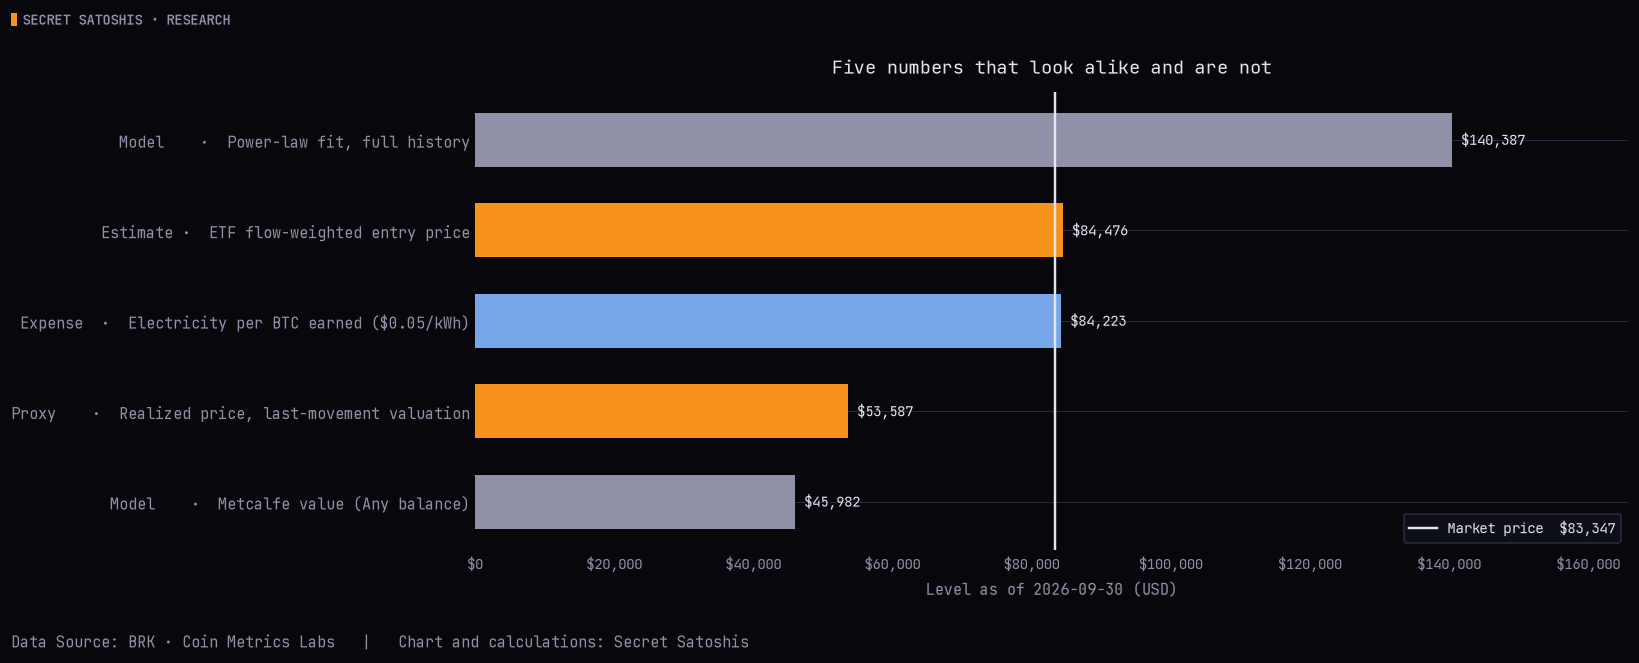

                                                           level   market ÷ it
Model    ·  Metcalfe value (Any balance)                  45,982         1.81x
Proxy    ·  Realized price, last-movement valuation        53,587         1.56x
Expense  ·  Electricity per BTC earned ($0.05/kWh)        84,223         0.99x
Estimate ·  ETF flow-weighted entry price                 84,476         0.99x
Model    ·  Power-law fit, full history                  140,387         0.59x
market price                                              83,347

Highest to lowest: 3.05x, from $45,982 to $140,387.
One is an entry-price estimate, one a ledger proxy, one an electricity expense, two are fits.
The span is not a range of likely values and should not be averaged.


In [21]:
# Five numbers that all look like a price. One is an entry-price estimate, one a ledger
# proxy, one an electricity expense, two are fitted models — the label carries which.
lens_series = {
    "Proxy    ·  Realized price, last-movement valuation": (rp, ORANGE),
    "Estimate ·  ETF flow-weighted entry price": (avg_paid, ORANGE),
    "Expense  ·  Electricity per BTC earned ($0.05/kWh)": (cost[MID], BLUE),
    f"Model    ·  Metcalfe value ({HEADLINE})": (fits[HEADLINE][0], GREY),
    "Model    ·  Power-law fit, full history": (model_pl, GREY),
}
aligned = pd.concat({name: series for name, (series, _) in lens_series.items()}, axis=1, sort=True)
aligned["market"] = px
aligned = aligned.replace([np.inf, -np.inf], np.nan).dropna()
if aligned.empty:
    raise ValueError("Price comparisons have no common valid date")
comparison_date = aligned.index[-1]
lenses = {name: (aligned.loc[comparison_date, name], color)
          for name, (_, color) in lens_series.items()}
market = aligned.loc[comparison_date, "market"]
print(f"All five levels and market price as of {comparison_date:%Y-%m-%d}.")

order = sorted(lenses.items(), key=lambda kv: kv[1][0])
names = [n for n, _ in order]
values = [v for _, (v, _) in order]
colors = [c for _, (_, c) in order]

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.barh(names, values, color=colors, height=.6)
ax.axvline(market, color=PRIMARY, linewidth=1.6, label=f"Market price  ${market:,.0f}")
for b, v in zip(bars, values):
    ax.annotate(f"${v:,.0f}", (v, b.get_y() + b.get_height() / 2), va="center",
                ha="left", fontsize=9, xytext=(6, 0), textcoords="offset points")
ax.set_xlim(0, max(values) * 1.18)
ax.set_xlabel(f"Level as of {comparison_date:%Y-%m-%d} (USD)")
ax.xaxis.set_major_formatter(FuncFormatter(usd))
ax.legend(fontsize=9, loc="lower right")
ax.tick_params(axis="y", labelsize=10)
finish(fig, "Five numbers that look alike and are not", ax, sources=[BRK, COIN_METRICS])

print(f"{'':<50}{'level':>14}{'market ÷ it':>14}")
for n, v in zip(names, values):
    print(f"{n:<50}{v:>14,.0f}{market / v:>13.2f}x")
print(f"{'market price':<50}{market:>14,.0f}")
print(f"\nHighest to lowest: {max(values) / min(values):.2f}x, from ${min(values):,.0f} to ${max(values):,.0f}.")
print("One is an entry-price estimate, one a ledger proxy, one an electricity expense, two are fits.")
print("The span is not a range of likely values and should not be averaged.")

---

# 6. Conclusion: observed traces, not a demand curve

Demand, properly, is how much people would buy at every possible price. We can only see what was bought at the prices that happened. Everything in this notebook is a trace left by that, so a demand curve was never on the table.

What each section did manage:

Mining priced one group of buyers from the outside, and separated new coins from fees. Addresses and realized price described the ledger accurately while failing to identify a single person or purchase. The ETF trusts produced the one clean stock and flow in the notebook, for one channel, without showing who is behind the shares. Company and government tables gave positions from mixed sources on dates that do not line up. The price relationships showed mostly how much the answer depends on how the question is asked.

The finding that runs across all of it is about measurement rather than about bitcoin: exposure can grow while the address count does not, because one custodian holds coins for thousands of people in one place. The numbers are consistent with that, and this notebook cannot prove custody is the only reason.

There is also a limit no amount of data fixes. Every trade has two sides. A rising balance can mean buyers wanted in badly, or sellers wanted out cheaply, or that money simply moved from one wrapper to another. Quantities alone cannot tell those apart.

Which leaves a ranking of what can be trusted. Protocol accounting and trust holdings are solid. Company and sovereign snapshots are real but scattered across dates. Owner estimates and the mapping from addresses to people are approximate. Models built on user counts or on time are conditional on their own assumptions.

And one claim worth carrying away: **an address count cannot measure ownership, and published disclosures are now a necessary second source.** Together they cover more than either does alone. Neither closes the gap between a trade we can see, a position somebody reports, and the demand that produced them.

---

## Data sources and terms

Each chart credits its sources in its footer. BRK, Coin Metrics Labs, World Bank, Our World in Data and Crypto.com data come through the [Bitcoin Report Library](https://github.com/SecretSatoshis/Bitcoin-Report-Library). Calculations — shares of population, flows, fits, ratios and totals — are Secret Satoshis'.

| Data | Source | Terms |
|---|---|---|
| Price, supply, issuance, fees, difficulty, hashrate, funded addresses, realized price | [BRK](https://bitview.space) (Bitcoin Research Kit), computed from the public blockchain | MIT-licensed open-source software; the data describes the public chain |
| Network mining efficiency | [Coin Metrics Labs](https://labs.coinmetrics.io/) | Creative Commons, non-commercial, with attribution |
| Internet users, population | [World Bank World Development Indicators](https://data.worldbank.org/) (ITU and UN data) | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/); shares calculated by Secret Satoshis; no endorsement implied |
| Internet users, 1990–2004 | [Our World in Data](https://ourworldindata.org/grapher/number-of-internet-users), from ITU | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) |
| Bitcoin owner estimates | [Crypto.com market sizing reports](https://crypto.com/research), one figure per year with its report linked in the release | Figures cited from published reports |
| US spot ETF holdings, flows and reported cost | Secret Satoshis ETF dataset: daily holdings and flows for each US spot bitcoin ETF, checked against each fund's 10-Q and 10-K filings on [SEC EDGAR](https://www.sec.gov/edgar/search/) | Compiled by Secret Satoshis; SEC filings are public |
| Company and government holdings | [CoinGecko](https://www.coingecko.com) public treasury API — Powered by CoinGecko | Displayed with attribution; CoinGecko's terms do not allow redistributing or storing the data, so its files are never published |
| Government acquisition types | Secret Satoshis classification, with a note per entity | Secret Satoshis |